In [1]:
import sys
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Add the project root to Python path
project_root = Path(__file__).parent.parent if '__file__' in globals() else Path.cwd().parent
sys.path.append(str(project_root))

# ML toolbox imports
from ml_toolbox.data_loader import DataLoader, create_windows_for_ml, create_label_to_class_map, extract_features_for_ml, FeatureConfig
from ml_toolbox.analysis.model_evaluation import evaluate_model_cv, cv_shap

# Initialize dataset manager
dataset_path = project_root / "data_set_4"
data_loader = DataLoader(dataset_path)
import hashlib
import json
from datetime import datetime, timezone
import joblib
import numpy as np

# Evaluate model
# Create pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', RandomForestClassifier(
        n_estimators=100,
        random_state=42, 
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2
    ))
])

# Caching strategy: one aligned bundle (labels + metadata + features, optional windows)
USE_BUNDLE_CACHE = True
CACHE_WINDOWS = False  # Keep False by default to avoid large cache files
USE_EVAL_CACHE = True
USE_SHAP_CACHE = True
FORCE_RECOMPUTE = False

cache_dir = project_root / "notebooks" / "test_output" / "cache"
cache_dir.mkdir(parents=True, exist_ok=True)
cache_meta_path = cache_dir / "ml_pipeline_cache_meta.json"
cache_meta = {}

# Canonical filter and processing params used for cache keys
load_params = {
    "classes": None,
    "loads": None,
    "frequencies": None,
    "sensor_types": "vibration",
    "sample_ids": None,
}
window_params = {
    "window_size": 10000,
    "overlap_ratio": 0.5,
    "max_windows_per_class": 4975,
    "shuffle": False,
    "random_state": 42,
}
# Feature Config
feat_conf = FeatureConfig(
    sensor_type="vibration",
    #selected_channels=["ch3", "ch4"]
)
feature_params = {
    "sensor_type": feat_conf.sensor_type,
    "selected_channels": list(feat_conf.selected_channels) if feat_conf.selected_channels is not None else None,
}

def _normalize_for_hashing(value):
    if isinstance(value, dict):
        return {k: _normalize_for_hashing(value[k]) for k in sorted(value)}
    if isinstance(value, (list, tuple, set)):
        return [_normalize_for_hashing(v) for v in sorted(value, key=lambda x: str(x))]
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.generic):
        return value.item()
    return value

# Build dataset fingerprint from filtered file descriptors (without loading waveforms)
filtered_files_for_key = data_loader.dataset_manager.filter_files(
    classes=load_params["classes"],
    loads=load_params["loads"],
    frequencies=load_params["frequencies"],
    sensor_types=load_params["sensor_types"],
    sample_ids=load_params["sample_ids"],
)
if not filtered_files_for_key:
    raise ValueError("No files match current load_params; cannot build cache key.")

fingerprint_rows = []
for item in sorted(
    filtered_files_for_key,
    key=lambda x: (
        str(x.get("sample_id", "")),
        str(x.get("sensor_type", "")),
        str(x.get("filename", "")),
        str(x.get("relative_path", x.get("path", ""))),
    ),
):
    fingerprint_rows.append({
        "sample_id": item.get("sample_id"),
        "sensor_type": item.get("sensor_type"),
        "filename": item.get("filename"),
        "relative_path": item.get("relative_path", item.get("path")),
        "load": item.get("load"),
        "electrical_frequency_hz": item.get("electrical_frequency_hz"),
        "pwm_frequency_hz": item.get("pwm_frequency_hz"),
    })

dataset_fingerprint_payload = {
    "dataset_path": str(dataset_path.resolve()),
    "file_count": len(fingerprint_rows),
    "rows": fingerprint_rows,
}
dataset_fingerprint = hashlib.sha256(
    json.dumps(dataset_fingerprint_payload, sort_keys=True, default=str).encode("utf-8")
).hexdigest()

bundle_key_payload = {
    "dataset_path": str(dataset_path.resolve()),
    "dataset_fingerprint": dataset_fingerprint,
    "load_params": _normalize_for_hashing(load_params),
    "window_params": _normalize_for_hashing(window_params),
    "feature_params": _normalize_for_hashing(feature_params),
}
bundle_key = hashlib.sha256(
    json.dumps(bundle_key_payload, sort_keys=True, default=str).encode("utf-8")
).hexdigest()
bundle_cache_path = cache_dir / f"bundle_{bundle_key}.joblib"
eval_cache_path = cache_dir / f"eval_res_{bundle_key}.joblib"
shap_cache_path = cache_dir / f"shap_res_{bundle_key}.joblib"

cache_meta.update({
    "bundle_key": bundle_key,
    "dataset_path": str(dataset_path.resolve()),
    "dataset_fingerprint": dataset_fingerprint,
    "bundle_cache_path": str(bundle_cache_path),
    "eval_cache_path": str(eval_cache_path),
    "shap_cache_path": str(shap_cache_path),
    "load_params": _normalize_for_hashing(load_params),
    "window_params": _normalize_for_hashing(window_params),
    "feature_params": _normalize_for_hashing(feature_params),
    "cache_windows": CACHE_WINDOWS,
})

# Load or compute one aligned bundle
bundle_loaded = False
if USE_BUNDLE_CACHE and bundle_cache_path.exists() and not FORCE_RECOMPUTE:
    bundle = joblib.load(bundle_cache_path)
    bundle_meta = bundle.get("meta", {})
    mismatch_reasons = []

    expected_meta = {
        "dataset_path": str(dataset_path.resolve()),
        "dataset_fingerprint": dataset_fingerprint,
        "load_params": _normalize_for_hashing(load_params),
        "window_params": _normalize_for_hashing(window_params),
        "feature_params": _normalize_for_hashing(feature_params),
    }
    for key, expected in expected_meta.items():
        actual = bundle_meta.get(key)
        if actual != expected:
            mismatch_reasons.append(f"{key} mismatch")

    required_keys = ["labels", "win_metadata", "features", "feature_names"]
    missing_keys = [k for k in required_keys if k not in bundle]
    if missing_keys:
        mismatch_reasons.append(f"missing payload keys: {missing_keys}")

    if mismatch_reasons:
        print("Bundle cache mismatch, recomputing:")
        for reason in mismatch_reasons:
            print(f"  - {reason}")
    else:
        labels = np.asarray(bundle["labels"], dtype=np.int32)
        win_metadata = list(bundle["win_metadata"])
        features = np.asarray(bundle["features"])
        feature_names = list(bundle["feature_names"])
        if CACHE_WINDOWS and "windows" in bundle:
            windows = np.asarray(bundle["windows"])
        elif CACHE_WINDOWS:
            print("Bundle cache does not include windows; continuing without cached windows.")
        cache_meta["bundle_source"] = "cache"
        bundle_loaded = True
        print(f"Loaded aligned bundle from cache: {bundle_cache_path}")

if not bundle_loaded:
    data, metadata = data_loader.load_batch(
        classes=load_params["classes"],
        loads=load_params["loads"],
        frequencies=load_params["frequencies"],
        sensor_types=load_params["sensor_types"],
        sample_ids=load_params["sample_ids"],
    )

    windows, labels, win_metadata = create_windows_for_ml(
        data_list=data,
        metadata_list=metadata,
        window_size=window_params["window_size"],
        overlap_ratio=window_params["overlap_ratio"],
        max_windows_per_class=window_params["max_windows_per_class"],
        shuffle=window_params["shuffle"],
        random_state=window_params["random_state"],
    )

    features, feature_names = extract_features_for_ml(
        windows,
        metadata_list=win_metadata,
        sensor_type=feat_conf.sensor_type,
        feature_config=feat_conf,
        include_categorical=False, # just try to remove categorial
    )

    bundle_payload = {
        "labels": np.asarray(labels, dtype=np.int32),
        "win_metadata": list(win_metadata),
        "features": np.asarray(features),
        "feature_names": list(feature_names),
        "meta": {
            "dataset_path": str(dataset_path.resolve()),
            "dataset_fingerprint": dataset_fingerprint,
            "load_params": _normalize_for_hashing(load_params),
            "window_params": _normalize_for_hashing(window_params),
            "feature_params": _normalize_for_hashing(feature_params),
            "created_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
            "include_windows": CACHE_WINDOWS,
        },
    }
    if CACHE_WINDOWS:
        bundle_payload["windows"] = np.asarray(windows)

    if USE_BUNDLE_CACHE:
        joblib.dump(bundle_payload, bundle_cache_path, compress=3)
        print(f"Computed and cached aligned bundle: {bundle_cache_path}")
    else:
        print("Bundle cache disabled: computed artifacts in-memory only")

    cache_meta["bundle_source"] = "computed"

# Safety checks for row alignment
if features.shape[0] != len(labels):
    raise ValueError(f"Row mismatch: features rows={features.shape[0]} != labels={len(labels)}")
if features.shape[0] != len(win_metadata):
    raise ValueError(
        f"Row mismatch: features rows={features.shape[0]} != win_metadata={len(win_metadata)}"
    )

cache_meta.update({
    "timestamp_utc": datetime.now(timezone.utc).isoformat(timespec="seconds"),
    "n_samples": int(features.shape[0]),
    "n_features": int(features.shape[1]),
    "rf_params": pipeline.named_steps["rf"].get_params(),
})

if USE_EVAL_CACHE and eval_cache_path.exists() and not FORCE_RECOMPUTE:
    eval_res = joblib.load(eval_cache_path)
    cache_meta["eval_res_source"] = "cache"
    print(f"Loaded eval_res from cache: {eval_cache_path}")
else:
    eval_res = evaluate_model_cv(
        pipeline,
        features,
        labels,
        win_metadata=win_metadata,
        parallel=True,
        n_jobs=8,
    )
    joblib.dump(eval_res, eval_cache_path, compress=3)
    cache_meta["eval_res_source"] = "computed"
    print(f"Computed and cached eval_res: {eval_cache_path}")

if USE_SHAP_CACHE and shap_cache_path.exists() and not FORCE_RECOMPUTE:
    shap_res = joblib.load(shap_cache_path)
    cache_meta["shap_res_source"] = "cache"
    print(f"Loaded shap_res from cache: {shap_cache_path}")
else:
    shap_res = cv_shap(
        pipeline,
        features,
        labels,
        win_metadata=win_metadata,
        parallel=True,
        n_jobs=8,
    )
    joblib.dump(shap_res, shap_cache_path, compress=3)
    cache_meta["shap_res_source"] = "computed"
    print(f"Computed and cached shap_res: {shap_cache_path}")

cache_meta_path.write_text(json.dumps(cache_meta, indent=2, default=str), encoding="utf-8")
print(f"Cache metadata updated: {cache_meta_path}")

Loaded aligned bundle from cache: d:\Istu\rul\health-asyn-ml\notebooks\test_output\cache\bundle_3f2791ce70d3758616afc8811c364deed3c2e3af97067aa2f50330efa0200460.joblib
Loaded eval_res from cache: d:\Istu\rul\health-asyn-ml\notebooks\test_output\cache\eval_res_3f2791ce70d3758616afc8811c364deed3c2e3af97067aa2f50330efa0200460.joblib
Loaded shap_res from cache: d:\Istu\rul\health-asyn-ml\notebooks\test_output\cache\shap_res_3f2791ce70d3758616afc8811c364deed3c2e3af97067aa2f50330efa0200460.joblib
Cache metadata updated: d:\Istu\rul\health-asyn-ml\notebooks\test_output\cache\ml_pipeline_cache_meta.json


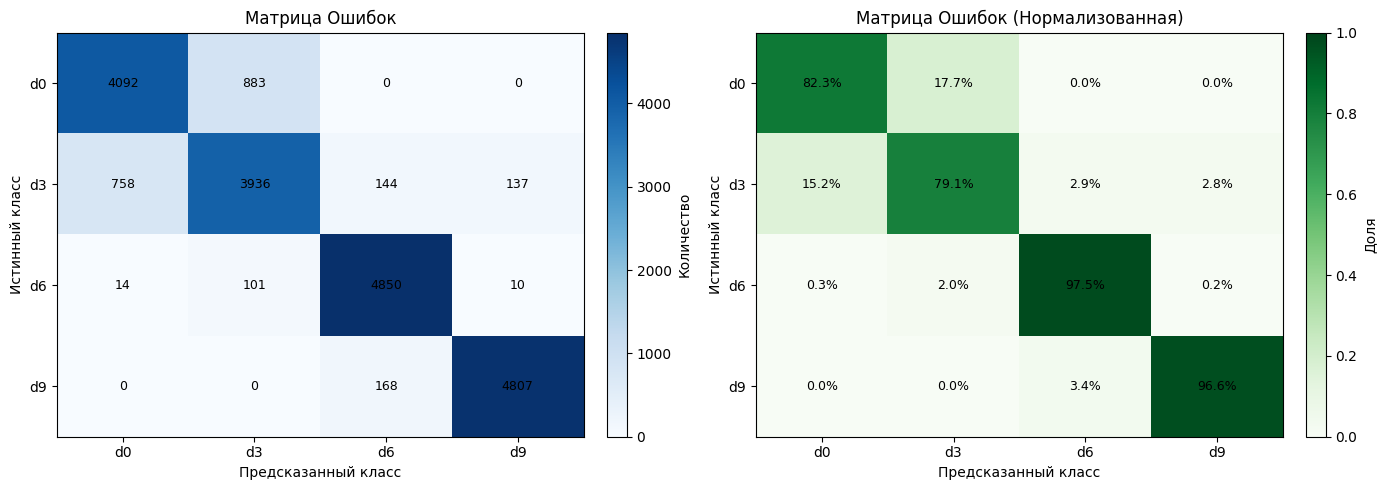

Mean CV Accuracy: 0.888 ± 0.052
Precision: 0.888, Recall: 0.889, F1: 0.888
Per-class CV metrics:
Class d0: P=0.841, R=0.823, F1=0.832
Class d3: P=0.800, R=0.791, F1=0.796
Class d6: P=0.940, R=0.975, F1=0.957
Class d9: P=0.970, R=0.966, F1=0.968


In [2]:
# Confusion Matrix (Out of Fold CV Predictions)
import numpy as np
import matplotlib.pyplot as plt

cm = np.asarray(eval_res["confusion_matrix"], dtype=float)
label_to_class = create_label_to_class_map(win_metadata)
labels_order = [label_to_class.get(int(lbl), str(lbl)) for lbl in eval_res["unique_labels"]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
im0 = axes[0].imshow(cm, cmap="Blues", aspect="auto")
axes[0].set_title(f"Матрица Ошибок")
axes[0].set_xlabel("Предсказанный класс")
axes[0].set_ylabel("Истинный класс")
axes[0].set_xticks(np.arange(len(labels_order)))
axes[0].set_yticks(np.arange(len(labels_order)))
axes[0].set_xticklabels(labels_order)
axes[0].set_yticklabels(labels_order)
plt.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04, label="Количество")

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        axes[0].text(j, i, f"{int(cm[i, j])}", ha="center", va="center", color="black", fontsize=9)

# Row-normalized percentages (per true class)
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm, row_sums, out=np.zeros_like(cm), where=row_sums != 0)

im1 = axes[1].imshow(cm_norm, cmap="Greens", aspect="auto", vmin=0.0, vmax=1.0)
axes[1].set_title("Матрица Ошибок (Нормализованная)")
axes[1].set_xlabel("Предсказанный класс")
axes[1].set_ylabel("Истинный класс")
axes[1].set_xticks(np.arange(len(labels_order)))
axes[1].set_yticks(np.arange(len(labels_order)))
axes[1].set_xticklabels(labels_order)
axes[1].set_yticklabels(labels_order)
plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04, label="Доля")

for i in range(cm_norm.shape[0]):
    for j in range(cm_norm.shape[1]):
        axes[1].text(j, i, f"{cm_norm[i, j] * 100:.1f}%", ha="center", va="center", color="black", fontsize=9)

plt.tight_layout()
plt.show()

print(f"Mean CV Accuracy: {eval_res['mean_accuracy']:.3f} ± {eval_res['std_accuracy']:.3f}")
print(f"Precision: {eval_res['precision']:.3f}, Recall: {eval_res['recall']:.3f}, F1: {eval_res['f1_score']:.3f}")

print("Per-class CV metrics:")
for idx, class_label in enumerate(labels_order):
    print(
        f"Class {class_label}: "
        f"P={eval_res['precision_per_class'][idx]:.3f}, "
        f"R={eval_res['recall_per_class'][idx]:.3f}, "
        f"F1={eval_res['f1_per_class'][idx]:.3f}"
    )

=== SHAP Analysis ===
Number of CV folds: 5
Classification type: Multiclass (4 classes)


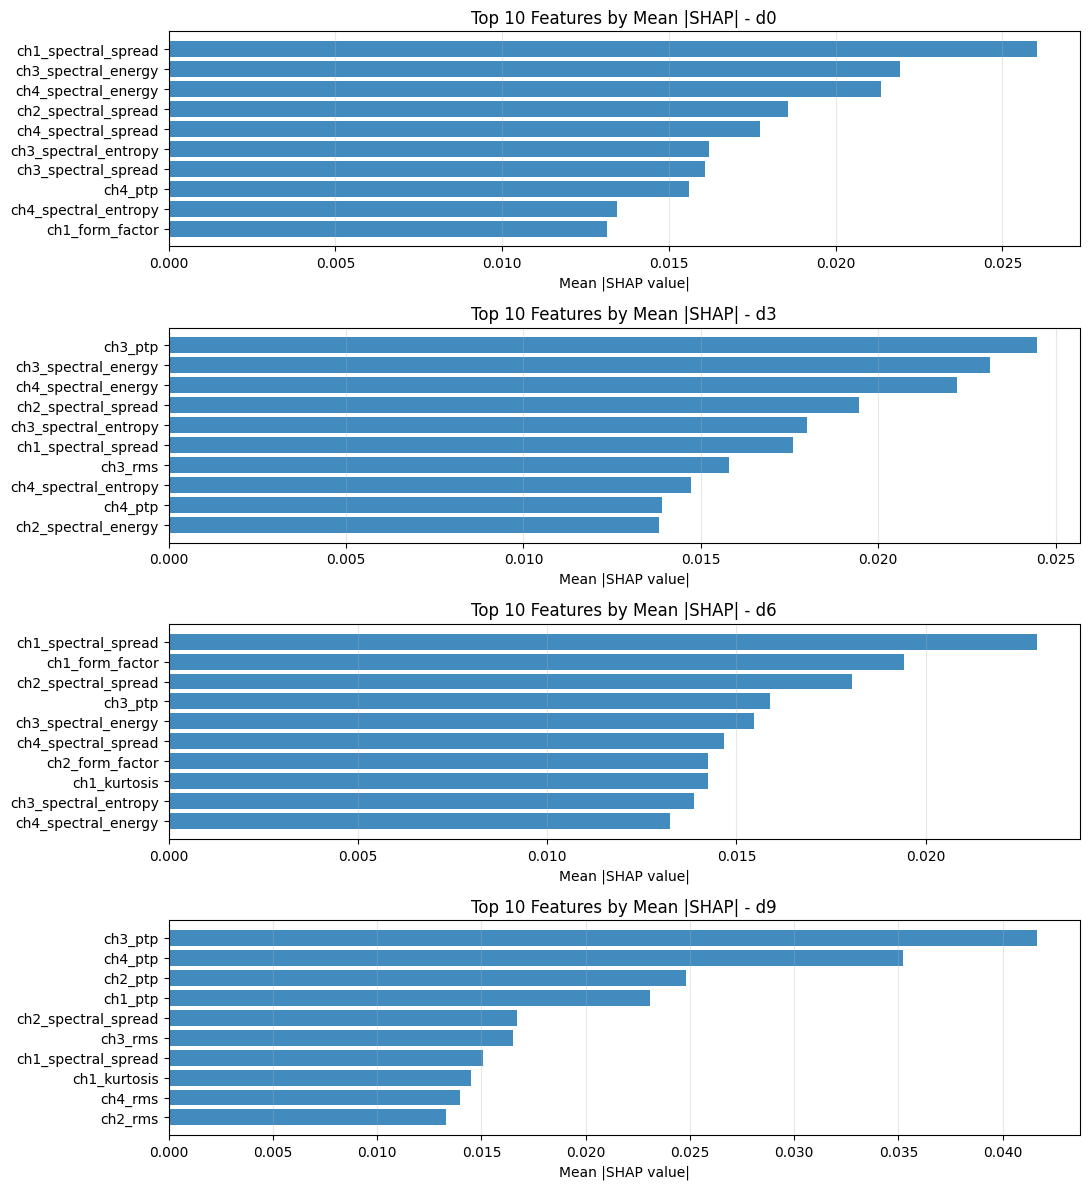

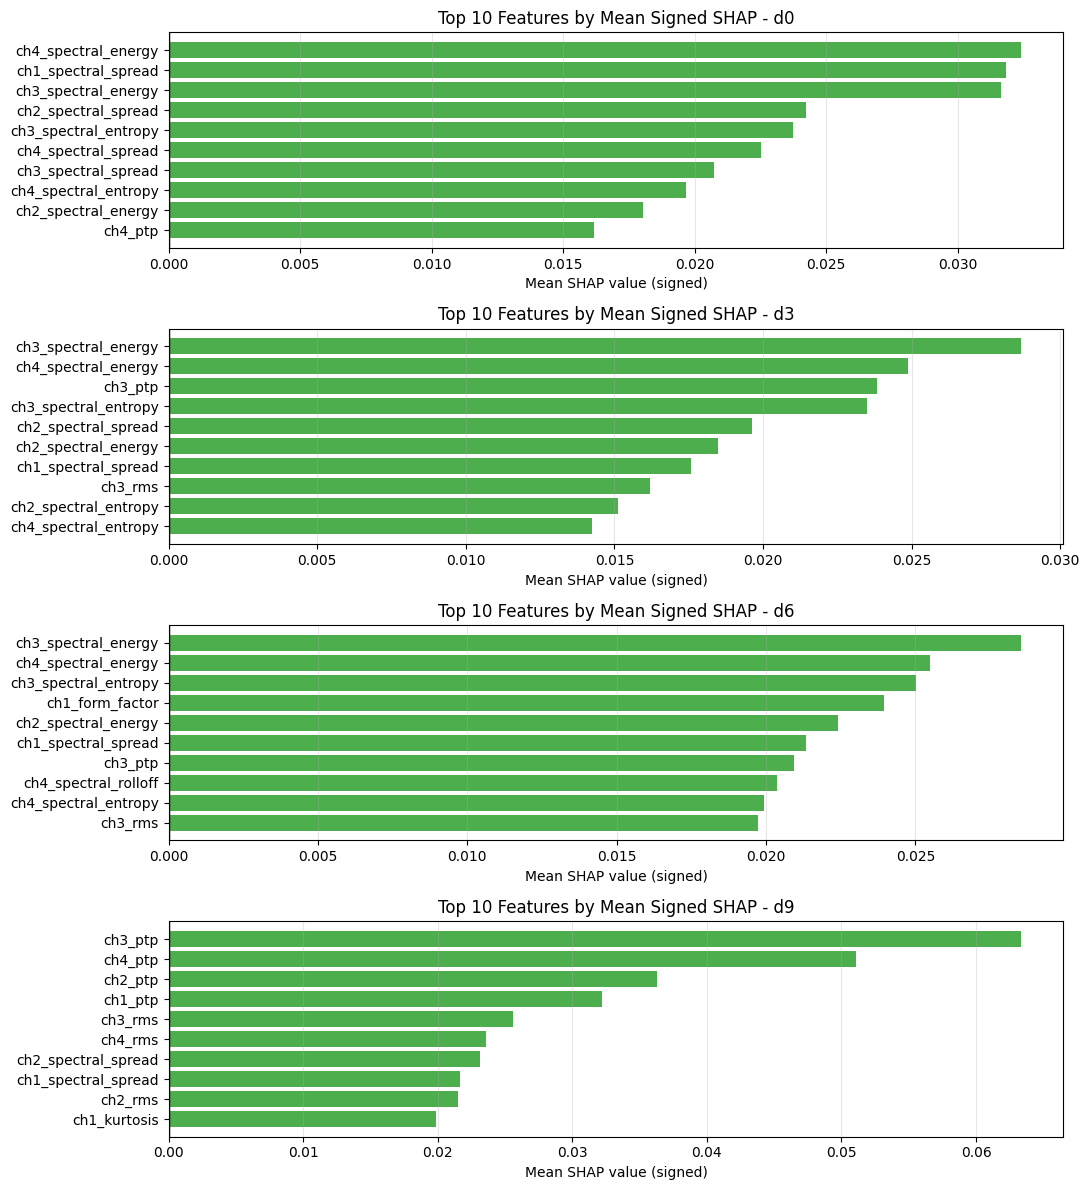

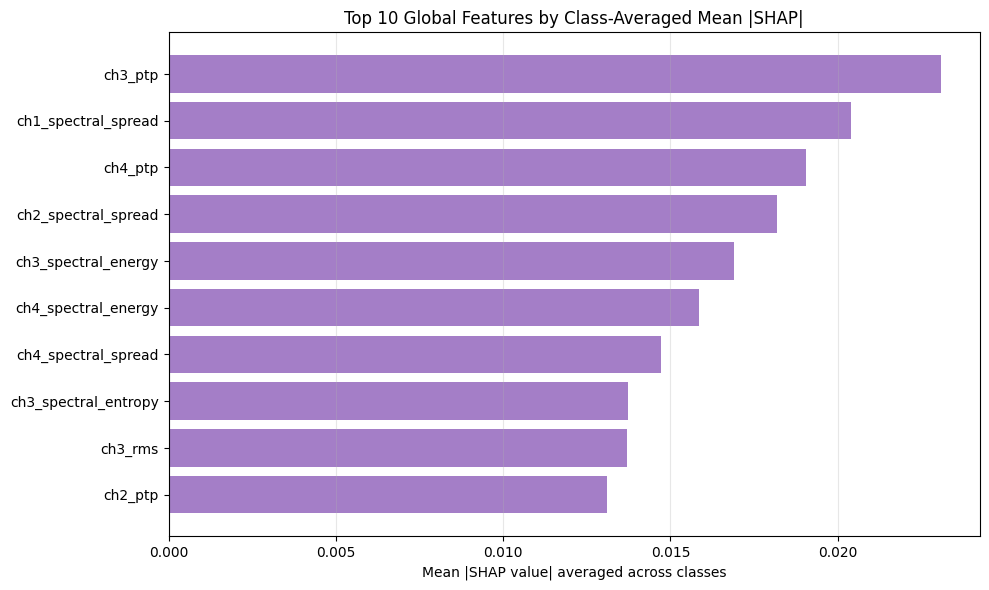


=== Per-class Top Features (Mean |SHAP|) ===

d0
 1. ch1_spectral_spread: 0.026025
 2. ch3_spectral_energy: 0.021945
 3. ch4_spectral_energy: 0.021355
 4. ch2_spectral_spread: 0.018573
 5. ch4_spectral_spread: 0.017742
 6. ch3_spectral_entropy: 0.016196
 7. ch3_spectral_spread: 0.016094
 8. ch4_ptp: 0.015589
 9. ch4_spectral_entropy: 0.013452
10. ch1_form_factor: 0.013158

d3
 1. ch3_ptp: 0.024464
 2. ch3_spectral_energy: 0.023156
 3. ch4_spectral_energy: 0.022230
 4. ch2_spectral_spread: 0.019463
 5. ch3_spectral_entropy: 0.018005
 6. ch1_spectral_spread: 0.017605
 7. ch3_rms: 0.015789
 8. ch4_spectral_entropy: 0.014735
 9. ch4_ptp: 0.013900
10. ch2_spectral_energy: 0.013810

d6
 1. ch1_spectral_spread: 0.022929
 2. ch1_form_factor: 0.019439
 3. ch2_spectral_spread: 0.018051
 4. ch3_ptp: 0.015893
 5. ch3_spectral_energy: 0.015460
 6. ch4_spectral_spread: 0.014676
 7. ch2_form_factor: 0.014248
 8. ch1_kurtosis: 0.014247
 9. ch3_spectral_entropy: 0.013874
10. ch4_spectral_energy: 0.013

In [3]:
# SHAP Analysis
import numpy as np
import matplotlib.pyplot as plt

top_how_many = 10

print("=== SHAP Analysis ===")
num_folds = len(shap_res["shap_values_per_fold"])
print(f"Number of CV folds: {num_folds}")

# Detect SHAP output format
first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
is_multiclass = isinstance(first_shap, list) or (hasattr(first_shap, "shape") and len(np.asarray(first_shap).shape) == 3)

if is_multiclass:
    if isinstance(first_shap, list):
        n_classes = len(first_shap)
    else:
        n_classes = np.asarray(first_shap).shape[2]
    print(f"Classification type: Multiclass ({n_classes} classes)")
else:
    n_classes = 1
    print("Classification type: Binary")

# Resolve display names for classes
unique_labels = np.asarray(eval_res.get("unique_labels", np.arange(n_classes)))
if unique_labels.size != n_classes:
    unique_labels = np.arange(n_classes)
label_to_class = create_label_to_class_map(win_metadata)
class_names = [label_to_class.get(int(lbl), f"Class {int(lbl)}") for lbl in unique_labels]
labels_arr = np.asarray(labels)

def _extract_class_shap(shap_values, class_idx):
    if isinstance(shap_values, list):
        return np.asarray(shap_values[class_idx])
    shap_arr = np.asarray(shap_values)
    if shap_arr.ndim == 3:
        return shap_arr[..., class_idx]
    return shap_arr

# Aggregate OOF SHAP values across folds per class
mean_abs_shap_per_class = []
mean_signed_shap_per_class = []

for class_idx in range(n_classes):
    src_class_idx = class_idx if is_multiclass else 0
    target_label = unique_labels[class_idx]

    shap_vals_class_all = []
    shap_vals_class_signed = []

    for fold in shap_res["shap_values_per_fold"]:
        shap_matrix = _extract_class_shap(fold["shap_values"], src_class_idx)
        shap_vals_class_all.append(shap_matrix)

        val_idx = np.asarray(fold["val_idx"])
        if shap_matrix.shape[0] != val_idx.shape[0]:
            raise ValueError(
                f"SHAP samples ({shap_matrix.shape[0]}) do not match val_idx length ({val_idx.shape[0]})."
            )
        y_true_fold = labels_arr[val_idx]
        class_mask = y_true_fold == target_label
        if np.any(class_mask):
            shap_vals_class_signed.append(shap_matrix[class_mask])

    all_shap_class = np.concatenate(shap_vals_class_all, axis=0)
    mean_abs_shap_per_class.append(np.mean(np.abs(all_shap_class), axis=0))

    if len(shap_vals_class_signed) == 0:
        raise ValueError(
            f"No samples found for class label {target_label} when computing signed SHAP means."
        )
    signed_shap_class = np.concatenate(shap_vals_class_signed, axis=0)
    mean_signed_shap_per_class.append(np.mean(signed_shap_class, axis=0))

mean_abs_shap_per_class = np.asarray(mean_abs_shap_per_class)
mean_signed_shap_per_class = np.asarray(mean_signed_shap_per_class)

# Keep this name for downstream cells that already use it
mean_shap_per_class = mean_abs_shap_per_class

top_n = min(top_how_many, mean_abs_shap_per_class.shape[1])

# 1) Mean absolute SHAP bars (importance ranking, per class)
fig, axes = plt.subplots(n_classes, 1, figsize=(11, max(4, 3 * n_classes)), squeeze=False)
for class_idx in range(n_classes):
    ax = axes[class_idx, 0]
    top_idx = np.argsort(mean_abs_shap_per_class[class_idx])[::-1][:top_n]
    top_vals = mean_abs_shap_per_class[class_idx][top_idx]
    top_feats = [feature_names[i] for i in top_idx]
    y_pos = np.arange(len(top_feats))

    ax.barh(y_pos, top_vals, color="tab:blue", alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats)
    ax.invert_yaxis()
    ax.set_xlabel("Mean |SHAP value|")
    ax.set_title(f"Top {top_n} Features by Mean |SHAP| - {class_names[class_idx]}")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# 2) Mean signed SHAP bars (directional average, per class)
fig, axes = plt.subplots(n_classes, 1, figsize=(11, max(4, 3 * n_classes)), squeeze=False)
for class_idx in range(n_classes):
    ax = axes[class_idx, 0]
    # Rank by absolute signed mean so both positive and negative drivers appear
    top_idx = np.argsort(np.abs(mean_signed_shap_per_class[class_idx]))[::-1][:top_n]
    top_vals = mean_signed_shap_per_class[class_idx][top_idx]
    top_feats = [feature_names[i] for i in top_idx]
    y_pos = np.arange(len(top_feats))
    colors = ["tab:green" if v >= 0 else "tab:red" for v in top_vals]

    ax.barh(y_pos, top_vals, color=colors, alpha=0.85)
    ax.axvline(0.0, color="black", linewidth=1.0)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(top_feats)
    ax.invert_yaxis()
    ax.set_xlabel("Mean SHAP value (signed)")
    ax.set_title(f"Top {top_n} Features by Mean Signed SHAP - {class_names[class_idx]}")
    ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

# 3) Average across classes (global multiclass overview)
avg_abs_shap_all_classes = np.mean(mean_abs_shap_per_class, axis=0)
avg_signed_shap_all_classes = np.mean(mean_signed_shap_per_class, axis=0)

top_idx_global = np.argsort(avg_abs_shap_all_classes)[::-1][:top_n]
top_vals_global = avg_abs_shap_all_classes[top_idx_global]
top_feats_global = [feature_names[i] for i in top_idx_global]
y_pos_global = np.arange(len(top_feats_global))

plt.figure(figsize=(10, 6))
plt.barh(y_pos_global, top_vals_global, color="tab:purple", alpha=0.85)
plt.yticks(y_pos_global, top_feats_global)
plt.gca().invert_yaxis()
plt.xlabel("Mean |SHAP value| averaged across classes")
plt.title(f"Top {top_n} Global Features by Class-Averaged Mean |SHAP|")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

# Mirrored text summary for logs/quick comparison
print("\n=== Per-class Top Features (Mean |SHAP|) ===")
for class_idx in range(n_classes):
    top_idx = np.argsort(mean_abs_shap_per_class[class_idx])[::-1][:top_n]
    print(f"\n{class_names[class_idx]}")
    for rank, feat_idx in enumerate(top_idx, start=1):
        print(f"{rank:2d}. {feature_names[feat_idx]}: {mean_abs_shap_per_class[class_idx][feat_idx]:.6f}")

print("\n=== Per-class Top Features (Mean Signed SHAP) ===")
for class_idx in range(n_classes):
    top_idx = np.argsort(np.abs(mean_signed_shap_per_class[class_idx]))[::-1][:top_n]
    print(f"\n{class_names[class_idx]}")
    for rank, feat_idx in enumerate(top_idx, start=1):
        print(f"{rank:2d}. {feature_names[feat_idx]}: {mean_signed_shap_per_class[class_idx][feat_idx]:+.6f}")

print("\n=== Global Top Features (Class-Averaged Mean |SHAP|) ===")
for rank, feat_idx in enumerate(top_idx_global, start=1):
    print(f"{rank:2d}. {feature_names[feat_idx]}: {avg_abs_shap_all_classes[feat_idx]:.6f}")

print(f"Mean absolute class-averaged signed SHAP magnitude: {np.mean(np.abs(avg_signed_shap_all_classes)):.6f}")
print(f"Total features analyzed: {mean_abs_shap_per_class.shape[1]}")

In [4]:
import numpy as np

k = 10
print("\n=== Per-class Bottom Features (Most Negative Mean Signed SHAP) ===")
for class_idx in range(n_classes):
    signed_vals = np.asarray(mean_signed_shap_per_class[class_idx])
    # Sort ascending and keep only truly negative contributors.
    neg_idx = [i for i in np.argsort(signed_vals) if signed_vals[i] < 0][:k]

    print(f"\n{class_names[class_idx]}")
    if len(neg_idx) == 0:
        print("No negative mean signed SHAP features for this class.")
    else:
        for rank, feat_idx in enumerate(neg_idx, start=1):
            print(f"{rank:2d}. {feature_names[feat_idx]}: {signed_vals[feat_idx]:+.6f}")

    # Per-feature negative-rate over true-class samples only.
    src_class_idx = class_idx if is_multiclass else 0
    target_label = unique_labels[class_idx]
    neg_counts = np.zeros_like(signed_vals, dtype=float)
    sample_count = 0

    for fold in shap_res["shap_values_per_fold"]:
        shap_matrix = _extract_class_shap(fold["shap_values"], src_class_idx)
        val_idx = np.asarray(fold["val_idx"])
        if shap_matrix.shape[0] != val_idx.shape[0]:
            raise ValueError(
                f"SHAP samples ({shap_matrix.shape[0]}) do not match val_idx length ({val_idx.shape[0]})."
            )
        y_true_fold = labels_arr[val_idx]
        class_mask = y_true_fold == target_label
        if not np.any(class_mask):
            continue

        class_shap = shap_matrix[class_mask]
        neg_counts += np.sum(class_shap < 0, axis=0)
        sample_count += class_shap.shape[0]

    if sample_count == 0:
        print("No true-class samples available to compute negative-rate.")
        continue

    neg_rate = neg_counts / sample_count
    top_neg_rate_idx = np.argsort(neg_rate)[::-1][:k]

    print("Top features by negative-rate (% of true-class samples with SHAP < 0):")
    for rank, feat_idx in enumerate(top_neg_rate_idx, start=1):
        print(
            f"{rank:2d}. {feature_names[feat_idx]}: {neg_rate[feat_idx] * 100:6.2f}% "
            f"(mean_signed={signed_vals[feat_idx]:+.6f})"
        )


=== Per-class Bottom Features (Most Negative Mean Signed SHAP) ===

d0
No negative mean signed SHAP features for this class.
Top features by negative-rate (% of true-class samples with SHAP < 0):
 1. ch3_spectral_energy:  46.43% (mean_signed=+0.031639)
 2. ch4_spectral_energy:  41.37% (mean_signed=+0.032405)
 3. ch3_spectral_entropy:  41.13% (mean_signed=+0.023748)
 4. ch3_skewness:  39.06% (mean_signed=+0.001367)
 5. ch4_skewness:  34.99% (mean_signed=+0.002891)
 6. ch1_skewness:  34.11% (mean_signed=+0.001303)
 7. ch4_spectral_entropy:  30.97% (mean_signed=+0.019679)
 8. ch2_form_factor:  30.55% (mean_signed=+0.010502)
 9. ch2_spectral_energy:  29.25% (mean_signed=+0.018030)
10. ch2_spectral_entropy:  29.19% (mean_signed=+0.014706)

d3
No negative mean signed SHAP features for this class.
Top features by negative-rate (% of true-class samples with SHAP < 0):
 1. ch2_skewness:  53.89% (mean_signed=+0.000314)
 2. ch4_skewness:  36.62% (mean_signed=+0.000476)
 3. ch3_kurtosis:  36.34% 

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _infer_shap_layout(shap_values):
    """Infer SHAP container format and class count from one fold output."""
    if isinstance(shap_values, list):
        if len(shap_values) == 0:
            raise ValueError("SHAP list format is empty.")
        return {"format": "list", "n_classes": len(shap_values)}

    arr = np.asarray(shap_values)
    if arr.ndim == 3:
        n_classes = arr.shape[2]
        if n_classes <= 1:
            return {"format": "binary3d", "n_classes": 1}
        return {"format": "array3d", "n_classes": n_classes}
    if arr.ndim == 2:
        return {"format": "array2d", "n_classes": 1}
    raise ValueError(f"Unsupported SHAP format with shape {arr.shape}.")

def _extract_class_shap_matrix(shap_values, class_idx, layout):
    """Return SHAP matrix with shape (n_samples, n_features) for one class."""
    fmt = layout["format"]
    if fmt == "list":
        if class_idx < 0 or class_idx >= len(shap_values):
            raise ValueError(f"class_idx={class_idx} is out of range for {len(shap_values)} classes.")
        return np.asarray(shap_values[class_idx])

    arr = np.asarray(shap_values)
    if fmt == "array3d":
        if class_idx < 0 or class_idx >= arr.shape[2]:
            raise ValueError(f"class_idx={class_idx} is out of range for {arr.shape[2]} classes.")
        return arr[..., class_idx]
    if fmt == "binary3d":
        if class_idx != 0:
            raise ValueError("Binary SHAP output supports only class_idx=0.")
        return arr[..., 0]
    if fmt == "array2d":
        if class_idx != 0:
            raise ValueError("Binary SHAP output supports only class_idx=0.")
        return arr

    raise ValueError(f"Unsupported SHAP format: {fmt}.")

def _resolve_class_idx(class_name, class_names):
    """Map class string to class index and fail loudly if not found."""
    if class_name not in class_names:
        available = ", ".join(class_names)
        raise ValueError(f"Unknown class_name='{class_name}'. Available classes: {available}")
    return int(class_names.index(class_name))

def _resolve_feature_idx(feature_name, feature_names):
    """Map feature string to feature index and fail loudly if not found."""
    if feature_name not in feature_names:
        preview = ", ".join(feature_names[:12])
        if len(feature_names) > 12:
            preview += ", ..."
        raise ValueError(
            f"Unknown feature_name='{feature_name}'. Available feature examples: {preview}"
        )
    return int(feature_names.index(feature_name))

def _validate_metadata_value(value, metadata_key, sample_idx):
    """Validate one metadata value used for coloring."""
    if value is None:
        raise ValueError(
            f"Missing value for metadata key '{metadata_key}' at sample index {sample_idx}."
        )
    if isinstance(value, (float, np.floating)) and np.isnan(value):
        raise ValueError(
            f"NaN value for metadata key '{metadata_key}' at sample index {sample_idx}."
        )
    return value

def _collect_scatter_data(shap_res, features, class_idx, feature_idx, layout=None, color_by=None, metadata_list=None):
    """Collect aligned feature values, SHAP values, and optional metadata across validation folds."""
    folds = shap_res.get("shap_values_per_fold", [])
    if len(folds) == 0:
        raise ValueError("shap_res['shap_values_per_fold'] is empty.")
    if feature_idx < 0 or feature_idx >= features.shape[1]:
        raise ValueError(f"feature_idx={feature_idx} is out of range [0, {features.shape[1] - 1}].")

    if layout is None:
        layout = _infer_shap_layout(folds[0]["shap_values"])

    collect_colors = color_by is not None
    if collect_colors:
        if metadata_list is None:
            raise ValueError("metadata_list is required when color_by is provided.")
        if len(metadata_list) != features.shape[0]:
            raise ValueError(
                f"metadata_list length ({len(metadata_list)}) must match number of feature rows ({features.shape[0]})."
            )

    x_parts = []
    y_parts = []
    color_parts = []

    for fold_no, fold in enumerate(folds):
        val_idx = np.asarray(fold["val_idx"])
        shap_matrix = _extract_class_shap_matrix(fold["shap_values"], class_idx, layout)

        if shap_matrix.ndim != 2:
            raise ValueError(f"Fold {fold_no}: expected 2D SHAP matrix, got shape {shap_matrix.shape}.")
        if shap_matrix.shape[0] != len(val_idx):
            raise ValueError(
                f"Fold {fold_no}: SHAP rows ({shap_matrix.shape[0]}) != len(val_idx) ({len(val_idx)})."
            )
        if shap_matrix.shape[1] != features.shape[1]:
            raise ValueError(
                f"Fold {fold_no}: SHAP features ({shap_matrix.shape[1]}) != features columns ({features.shape[1]})."
            )

        x_parts.append(features[val_idx, feature_idx])
        y_parts.append(shap_matrix[:, feature_idx])

        if collect_colors:
            fold_colors = []
            for sample_idx in val_idx:
                meta = metadata_list[int(sample_idx)]
                if not isinstance(meta, dict):
                    raise ValueError(
                        f"metadata_list[{int(sample_idx)}] must be a dict, got {type(meta).__name__}."
                    )
                if color_by not in meta:
                    raise ValueError(
                        f"Metadata key '{color_by}' not found at sample index {int(sample_idx)}."
                    )
                fold_colors.append(
                    _validate_metadata_value(meta[color_by], metadata_key=color_by, sample_idx=int(sample_idx))
                )
            color_parts.append(np.asarray(fold_colors, dtype=object))

    x_vals = np.concatenate(x_parts, axis=0)
    y_vals = np.concatenate(y_parts, axis=0)

    if not collect_colors:
        return x_vals, y_vals, None

    color_vals = np.concatenate(color_parts, axis=0)
    if color_vals.shape[0] != x_vals.shape[0]:
        raise ValueError(
            f"Color values length ({color_vals.shape[0]}) must match scatter points ({x_vals.shape[0]})."
        )

    return x_vals, y_vals, color_vals

def _build_discrete_colors(values, cmap_name="tab20"):
    """Create deterministic color mapping for discrete metadata categories."""
    values = np.asarray(values, dtype=object)
    unique_vals = sorted(np.unique(values), key=lambda x: str(x))
    cmap = plt.get_cmap(cmap_name, max(len(unique_vals), 1))
    value_to_color = {val: cmap(i) for i, val in enumerate(unique_vals)}
    point_colors = [value_to_color[val] for val in values]
    return unique_vals, value_to_color, point_colors

def plot_shap_scatter(
    class_name,
    feature_name,
    use_abs=False,
    alpha=0.6,
    figsize=(8, 6),
    marker_size=2,
    color_by=None,
    color_palette="tab20",
):
    """Plot SHAP scatter by class and feature, with optional metadata colorization.

    Example:
        plot_shap_scatter(class_name="d0", feature_name="ch3_ptp")
        plot_shap_scatter(class_name="d0", feature_name="ch3_ptp", color_by="electrical_frequency_hz")
    """
    if not isinstance(class_name, str) or class_name.strip() == "":
        raise ValueError("class_name must be a non-empty string.")
    if not isinstance(feature_name, str) or feature_name.strip() == "":
        raise ValueError("feature_name must be a non-empty string.")
    if color_by is not None and (not isinstance(color_by, str) or color_by.strip() == ""):
        raise ValueError("color_by must be None or a non-empty metadata key string.")

    resolved_class_names = class_names if "class_names" in globals() else labels_order
    class_idx = _resolve_class_idx(class_name=class_name, class_names=list(resolved_class_names))
    feature_idx = _resolve_feature_idx(feature_name=feature_name, feature_names=list(feature_names))

    first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
    layout = _infer_shap_layout(first_shap)
    if layout["n_classes"] == 1 and class_idx != 0:
        raise ValueError("Binary SHAP output has only one class; use class_name of index 0.")

    x_vals, y_vals, color_vals = _collect_scatter_data(
        shap_res=shap_res,
        features=features,
        class_idx=class_idx,
        feature_idx=feature_idx,
        layout=layout,
        color_by=color_by,
        metadata_list=win_metadata if color_by is not None else None,
    )

    y_plot = np.abs(y_vals) if use_abs else y_vals
    y_label = "|SHAP Value|" if use_abs else "SHAP Value"

    plt.figure(figsize=figsize)

    category_counts = None
    if color_by is None:
        plt.scatter(x=x_vals, y=y_plot, alpha=alpha, s=float(marker_size) * 2.0,)
    else:
        unique_vals, value_to_color, point_colors = _build_discrete_colors(
            values=color_vals,
            cmap_name=color_palette,
        )
        plt.scatter(x=x_vals, y=y_plot, c=point_colors, alpha=alpha, s=float(marker_size) * 2.0,)

        handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=str(val),
                markerfacecolor=value_to_color[val],
                markersize=8,
            )
            for val in unique_vals
        ]
        plt.legend(handles=handles, title=color_by, loc="best", frameon=True)
        category_counts = {str(val): int(np.sum(color_vals == val)) for val in unique_vals}

    plt.xlabel(f"Feature Value: {feature_name}")
    plt.ylabel(y_label)
    title = f"SHAP Scatter - {class_name} | {feature_name}"
    if color_by is not None:
        title += f" | color: {color_by}"
    plt.title(title)
    plt.grid(True, alpha=0.3)
    
    #save_path = "test_output/pic"
    #plt.savefig(f"{save_path}/shap_scatter_{class_name}_{feature_name}_color_{color_by}.png", dpi=300, bbox_inches="tight")

    plt.show()

    return {
        "class_name": class_name,
        "feature_name": feature_name,
        "class_idx": class_idx,
        "feature_idx": feature_idx,
        "n_points": int(len(x_vals)),
        "color_by": color_by,
        "color_categories": category_counts,
    }

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _collect_dependence_interaction_data(
    shap_res,
    features,
    class_idx,
    feature_idx,
    interaction_feature_idx,
    layout=None,
    color_by=None,
    metadata_list=None,
):
    """Collect dependence-style SHAP data across validation folds.

    Returns:
        x_vals: feature values for primary feature
        y_vals: SHAP values for primary feature
        interaction_vals: feature values for interaction feature
        color_vals: optional metadata values when color_by is provided
    """
    folds = shap_res.get("shap_values_per_fold", [])
    if len(folds) == 0:
        raise ValueError("shap_res['shap_values_per_fold'] is empty.")

    if feature_idx < 0 or feature_idx >= features.shape[1]:
        raise ValueError(f"feature_idx={feature_idx} is out of range [0, {features.shape[1] - 1}].")
    if interaction_feature_idx < 0 or interaction_feature_idx >= features.shape[1]:
        raise ValueError(
            f"interaction_feature_idx={interaction_feature_idx} is out of range [0, {features.shape[1] - 1}]."
        )

    if layout is None:
        layout = _infer_shap_layout(folds[0]["shap_values"])

    collect_colors = color_by is not None
    if collect_colors:
        if metadata_list is None:
            raise ValueError("metadata_list is required when color_by is provided.")
        if len(metadata_list) != features.shape[0]:
            raise ValueError(
                f"metadata_list length ({len(metadata_list)}) must match number of feature rows ({features.shape[0]})."
            )

    x_parts = []
    y_parts = []
    interaction_parts = []
    color_parts = []

    for fold_no, fold in enumerate(folds):
        val_idx = np.asarray(fold["val_idx"])
        shap_matrix = _extract_class_shap_matrix(fold["shap_values"], class_idx, layout)

        if shap_matrix.ndim != 2:
            raise ValueError(f"Fold {fold_no}: expected 2D SHAP matrix, got shape {shap_matrix.shape}.")
        if shap_matrix.shape[0] != len(val_idx):
            raise ValueError(
                f"Fold {fold_no}: SHAP rows ({shap_matrix.shape[0]}) != len(val_idx) ({len(val_idx)})."
            )
        if shap_matrix.shape[1] != features.shape[1]:
            raise ValueError(
                f"Fold {fold_no}: SHAP features ({shap_matrix.shape[1]}) != features columns ({features.shape[1]})."
            )

        x_parts.append(features[val_idx, feature_idx])
        y_parts.append(shap_matrix[:, feature_idx])
        interaction_parts.append(features[val_idx, interaction_feature_idx])

        if collect_colors:
            fold_colors = []
            for sample_idx in val_idx:
                meta = metadata_list[int(sample_idx)]
                if not isinstance(meta, dict):
                    raise ValueError(
                        f"metadata_list[{int(sample_idx)}] must be a dict, got {type(meta).__name__}."
                    )
                if color_by not in meta:
                    raise ValueError(
                        f"Metadata key '{color_by}' not found at sample index {int(sample_idx)}."
                    )
                fold_colors.append(
                    _validate_metadata_value(meta[color_by], metadata_key=color_by, sample_idx=int(sample_idx))
                )
            color_parts.append(np.asarray(fold_colors, dtype=object))

    x_vals = np.concatenate(x_parts, axis=0)
    y_vals = np.concatenate(y_parts, axis=0)
    interaction_vals = np.concatenate(interaction_parts, axis=0)

    if x_vals.shape[0] != y_vals.shape[0] or x_vals.shape[0] != interaction_vals.shape[0]:
        raise ValueError("Collected arrays for dependence plot are not aligned.")

    if not collect_colors:
        return x_vals, y_vals, interaction_vals, None

    color_vals = np.concatenate(color_parts, axis=0)
    if color_vals.shape[0] != x_vals.shape[0]:
        raise ValueError(
            f"Color values length ({color_vals.shape[0]}) must match scatter points ({x_vals.shape[0]})."
        )

    return x_vals, y_vals, interaction_vals, color_vals

def plot_shap_dependence_interaction(
    class_name,
    feature_name,
    interaction_feature_name,
    use_abs=False,
    alpha=0.6,
    figsize=(8, 6),
    color_by=None,
    continuous_cmap="viridis",
    discrete_palette="tab20",
):
    """Plot SHAP dependence with interaction coloring.

    Dependence-style view:
      - x-axis: primary feature value
      - y-axis: SHAP value of primary feature
      - color: interaction feature value (continuous) or metadata key (discrete via color_by)
    """
    if not isinstance(class_name, str) or class_name.strip() == "":
        raise ValueError("class_name must be a non-empty string.")
    if not isinstance(feature_name, str) or feature_name.strip() == "":
        raise ValueError("feature_name must be a non-empty string.")
    if not isinstance(interaction_feature_name, str) or interaction_feature_name.strip() == "":
        raise ValueError("interaction_feature_name must be a non-empty string.")
    if color_by is not None and (not isinstance(color_by, str) or color_by.strip() == ""):
        raise ValueError("color_by must be None or a non-empty metadata key string.")

    resolved_class_names = class_names if "class_names" in globals() else labels_order
    class_idx = _resolve_class_idx(class_name=class_name, class_names=list(resolved_class_names))
    feature_idx = _resolve_feature_idx(feature_name=feature_name, feature_names=list(feature_names))
    interaction_feature_idx = _resolve_feature_idx(
        feature_name=interaction_feature_name,
        feature_names=list(feature_names),
    )

    if feature_idx == interaction_feature_idx:
        raise ValueError(
            "feature_name and interaction_feature_name must be different for interaction visualization."
        )

    first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
    layout = _infer_shap_layout(first_shap)
    if layout["n_classes"] == 1 and class_idx != 0:
        raise ValueError("Binary SHAP output has only one class; use class_name of index 0.")

    x_vals, y_vals, interaction_vals, color_vals = _collect_dependence_interaction_data(
        shap_res=shap_res,
        features=features,
        class_idx=class_idx,
        feature_idx=feature_idx,
        interaction_feature_idx=interaction_feature_idx,
        layout=layout,
        color_by=color_by,
        metadata_list=win_metadata if color_by is not None else None,
    )

    y_plot = np.abs(y_vals) if use_abs else y_vals
    y_label = "|SHAP Value|" if use_abs else "SHAP Value"

    plt.figure(figsize=figsize)

    category_counts = None
    color_source = interaction_feature_name
    color_mode = "continuous_feature"

    if color_by is None:
        sc = plt.scatter(
            x=x_vals,
            y=y_plot,
            c=interaction_vals,
            cmap=continuous_cmap,
            alpha=alpha,
        )
        cbar = plt.colorbar(sc)
        cbar.set_label(f"Interaction feature value: {interaction_feature_name}")
    else:
        unique_vals, value_to_color, point_colors = _build_discrete_colors(
            values=color_vals,
            cmap_name=discrete_palette,
        )
        plt.scatter(x=x_vals, y=y_plot, c=point_colors, alpha=alpha)

        handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=str(val),
                markerfacecolor=value_to_color[val],
                markersize=8,
                alpha=alpha,
            )
            for val in unique_vals
        ]
        plt.legend(handles=handles, title=color_by, loc="best", frameon=True)
        category_counts = {str(val): int(np.sum(color_vals == val)) for val in unique_vals}
        color_source = color_by
        color_mode = "discrete_metadata"

    plt.xlabel(f"Feature Value: {feature_name}")
    plt.ylabel(y_label)
    title = f"SHAP Dependence Interaction - {class_name} | {feature_name} x {interaction_feature_name}"
    if color_by is not None:
        title += f" | color: {color_by}"
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.show()

    corr = np.nan
    if x_vals.size > 1 and y_vals.size > 1:
        corr = float(np.corrcoef(x_vals, y_vals)[0, 1])

    return {
        "class_name": class_name,
        "feature_name": feature_name,
        "interaction_feature_name": interaction_feature_name,
        "class_idx": class_idx,
        "feature_idx": feature_idx,
        "interaction_feature_idx": interaction_feature_idx,
        "n_points": int(len(x_vals)),
        "color_by": color_by,
        "color_source": color_source,
        "color_mode": color_mode,
        "color_categories": category_counts,
        "feature_shap_correlation": corr,
    }

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def _collect_oof_predictions(shap_res, features):
    """Reconstruct out-of-fold predictions from cv_shap estimators."""
    estimators = shap_res.get("estimators", None)
    if estimators is None or len(estimators) == 0:
        raise ValueError("shap_res['estimators'] is empty. Cannot reconstruct OOF predictions.")

    n_samples = int(features.shape[0])
    oof_pred = np.empty(n_samples, dtype=object)
    filled = np.zeros(n_samples, dtype=bool)

    for fold_no, est_item in enumerate(estimators):
        if not isinstance(est_item, (tuple, list)) or len(est_item) != 2:
            raise ValueError(
                f"Fold {fold_no}: expected (estimator, val_idx), got {type(est_item).__name__}."
            )

        estimator, val_idx = est_item
        val_idx = np.asarray(val_idx, dtype=int)
        if val_idx.ndim != 1:
            raise ValueError(f"Fold {fold_no}: val_idx must be 1D, got shape {val_idx.shape}.")
        if np.any(val_idx < 0) or np.any(val_idx >= n_samples):
            raise ValueError(f"Fold {fold_no}: val_idx contains out-of-range indices.")
        if np.any(filled[val_idx]):
            raise ValueError(f"Fold {fold_no}: overlapping validation indices detected in estimators.")

        fold_pred = np.asarray(estimator.predict(features[val_idx]), dtype=object)
        if fold_pred.shape[0] != val_idx.shape[0]:
            raise ValueError(
                f"Fold {fold_no}: prediction length ({fold_pred.shape[0]}) != val_idx length ({val_idx.shape[0]})."
            )

        oof_pred[val_idx] = fold_pred
        filled[val_idx] = True

    if not np.all(filled):
        missing = np.flatnonzero(~filled)
        preview = ", ".join(map(str, missing[:10]))
        if missing.size > 10:
            preview += ", ..."
        raise ValueError(
            f"OOF coverage incomplete: {missing.size} samples are missing predictions at indices [{preview}]."
        )

    return oof_pred

def plot_feature_space_predicted_classes(
    feature_a_name,
    feature_b_name,
    alpha=0.65,
    marker_size=18,
    figsize=(8, 6),
    color_palette="tab20",
    show_misclassified=True,
):
    """Plot class separation in 2D feature space, colored by OOF predicted class."""
    if not isinstance(feature_a_name, str) or feature_a_name.strip() == "":
        raise ValueError("feature_a_name must be a non-empty string.")
    if not isinstance(feature_b_name, str) or feature_b_name.strip() == "":
        raise ValueError("feature_b_name must be a non-empty string.")

    features_arr = np.asarray(features)
    labels_arr = np.asarray(labels)
    if features_arr.ndim != 2:
        raise ValueError(f"features must be 2D, got shape {features_arr.shape}.")
    if labels_arr.shape[0] != features_arr.shape[0]:
        raise ValueError(
            f"Row mismatch: labels length ({labels_arr.shape[0]}) != features rows ({features_arr.shape[0]})."
        )

    feature_a_idx = _resolve_feature_idx(feature_name=feature_a_name, feature_names=list(feature_names))
    feature_b_idx = _resolve_feature_idx(feature_name=feature_b_name, feature_names=list(feature_names))
    if feature_a_idx == feature_b_idx:
        raise ValueError("feature_a_name and feature_b_name must refer to different features.")

    pred_oof = _collect_oof_predictions(shap_res=shap_res, features=features_arr)

    resolved_class_names = class_names if "class_names" in globals() else (labels_order if "labels_order" in globals() else None)
    eval_unique_labels = np.asarray(eval_res.get("unique_labels", np.unique(labels_arr)))

    label_to_name = {}
    if resolved_class_names is not None and len(resolved_class_names) == len(eval_unique_labels):
        label_to_name = {int(lbl): str(resolved_class_names[i]) for i, lbl in enumerate(eval_unique_labels)}
    else:
        for lbl in np.unique(np.concatenate([labels_arr.astype(object), pred_oof.astype(object)])):
            try:
                label_to_name[int(lbl)] = f"Class {int(lbl)}"
            except Exception:
                label_to_name[lbl] = str(lbl)

    pred_unique = sorted(np.unique(pred_oof), key=lambda x: str(x))
    cmap = plt.get_cmap(color_palette, max(len(pred_unique), 1))
    pred_label_to_color = {lbl: cmap(i) for i, lbl in enumerate(pred_unique)}
    point_colors = [pred_label_to_color[lbl] for lbl in pred_oof]

    x_vals = features_arr[:, feature_a_idx]
    y_vals = features_arr[:, feature_b_idx]

    plt.figure(figsize=figsize)
    plt.scatter(x_vals, y_vals, c=point_colors, s=marker_size, alpha=alpha)

    misclassified_mask = pred_oof != labels_arr.astype(object)
    if show_misclassified and np.any(misclassified_mask):
        plt.scatter(
            x_vals[misclassified_mask],
            y_vals[misclassified_mask],
            facecolors="none",
            edgecolors="black",
            s=marker_size * 2,
            linewidths=0.2,
        )

    handles = []
    pred_counts = {}
    for lbl in pred_unique:
        count = int(np.sum(pred_oof == lbl))
        pred_counts[str(lbl)] = count
        display_name = label_to_name.get(int(lbl), str(lbl)) if isinstance(lbl, (int, np.integer)) else label_to_name.get(lbl, str(lbl))
        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=f"Pred {display_name} (n={count})",
                markerfacecolor=pred_label_to_color[lbl],
                markersize=8,
            )
        )
    if show_misclassified and np.any(misclassified_mask):
        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="black",
                label=f"Misclassified (n={int(np.sum(misclassified_mask))})",
                markerfacecolor="none",
                markersize=8,
                linewidth=0
            )
        )

    plt.legend(handles=handles, title="Predicted class", loc="best", frameon=True)
    plt.xlabel(f"Feature A: {feature_a_name}")
    plt.ylabel(f"Feature B: {feature_b_name}")
    plt.title("Class separation in feature space (color = OOF predicted class)")
    plt.grid(True, alpha=0.3)
    plt.show()

    subset_accuracy = float(np.mean(pred_oof == labels_arr.astype(object)))
    return {
        "feature_a_name": feature_a_name,
        "feature_b_name": feature_b_name,
        "feature_a_idx": int(feature_a_idx),
        "feature_b_idx": int(feature_b_idx),
        "n_points": int(features_arr.shape[0]),
        "predicted_class_counts": pred_counts,
        "misclassified_count": int(np.sum(misclassified_mask)),
        "subset_accuracy": subset_accuracy,
    }

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_feature_space_true_classes_with_pred_overlay(
    feature_a_name,
    feature_b_name,
    alpha=0.65,
    marker_size=18,
    figsize=(8, 6),
    color_palette="tab20",
    show_misclassified=True,
):
    """Plot feature space colored by true class, with misclassified samples outlined.

    This complements plot_feature_space_predicted_classes() where colors represent predictions.
    """
    if not isinstance(feature_a_name, str) or feature_a_name.strip() == "":
        raise ValueError("feature_a_name must be a non-empty string.")
    if not isinstance(feature_b_name, str) or feature_b_name.strip() == "":
        raise ValueError("feature_b_name must be a non-empty string.")

    features_arr = np.asarray(features)
    labels_arr = np.asarray(labels)
    if features_arr.ndim != 2:
        raise ValueError(f"features must be 2D, got shape {features_arr.shape}.")
    if labels_arr.shape[0] != features_arr.shape[0]:
        raise ValueError(
            f"Row mismatch: labels length ({labels_arr.shape[0]}) != features rows ({features_arr.shape[0]})."
        )

    feature_a_idx = _resolve_feature_idx(feature_name=feature_a_name, feature_names=list(feature_names))
    feature_b_idx = _resolve_feature_idx(feature_name=feature_b_name, feature_names=list(feature_names))
    if feature_a_idx == feature_b_idx:
        raise ValueError("feature_a_name and feature_b_name must refer to different features.")

    pred_oof = _collect_oof_predictions(shap_res=shap_res, features=features_arr)

    resolved_class_names = class_names if "class_names" in globals() else (labels_order if "labels_order" in globals() else None)
    eval_unique_labels = np.asarray(eval_res.get("unique_labels", np.unique(labels_arr)))

    label_to_name = {}
    if resolved_class_names is not None and len(resolved_class_names) == len(eval_unique_labels):
        label_to_name = {int(lbl): str(resolved_class_names[i]) for i, lbl in enumerate(eval_unique_labels)}
    else:
        for lbl in np.unique(labels_arr):
            try:
                label_to_name[int(lbl)] = f"Class {int(lbl)}"
            except Exception:
                label_to_name[lbl] = str(lbl)

    true_unique = sorted(np.unique(labels_arr), key=lambda x: str(x))
    cmap = plt.get_cmap(color_palette, max(len(true_unique), 1))
    true_label_to_color = {lbl: cmap(i) for i, lbl in enumerate(true_unique)}
    point_colors = [true_label_to_color[lbl] for lbl in labels_arr]

    x_vals = features_arr[:, feature_a_idx]
    y_vals = features_arr[:, feature_b_idx]

    plt.figure(figsize=figsize)
    plt.scatter(x_vals, y_vals, c=point_colors, s=marker_size, alpha=alpha)

    misclassified_mask = pred_oof != labels_arr.astype(object)
    if show_misclassified and np.any(misclassified_mask):
        plt.scatter(
            x_vals[misclassified_mask],
            y_vals[misclassified_mask],
            facecolors="none",
            edgecolors="black",
            s=marker_size,
            linewidths=0.8,
        )

    handles = []
    true_counts = {}
    for lbl in true_unique:
        count = int(np.sum(labels_arr == lbl))
        true_counts[str(lbl)] = count
        display_name = label_to_name.get(int(lbl), str(lbl)) if isinstance(lbl, (int, np.integer)) else label_to_name.get(lbl, str(lbl))
        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=f"True {display_name} (n={count})",
                markerfacecolor=true_label_to_color[lbl],
                markersize=8,
            )
        )
    if show_misclassified and np.any(misclassified_mask):
        handles.append(
            Line2D(
                [0],
                [0],
                marker="o",
                color="black",
                label=f"Misclassified (n={int(np.sum(misclassified_mask))})",
                markerfacecolor="none",
                markersize=8,
                linewidth=0,
            )
        )

    plt.legend(handles=handles, title="True class", loc="best", frameon=True)
    plt.xlabel(f"Feature A: {feature_a_name}")
    plt.ylabel(f"Feature B: {feature_b_name}")
    plt.title("Class separation in feature space (color = true class)")
    plt.grid(True, alpha=0.3)
    plt.show()

    subset_accuracy = float(np.mean(pred_oof == labels_arr.astype(object)))
    return {
        "feature_a_name": feature_a_name,
        "feature_b_name": feature_b_name,
        "feature_a_idx": int(feature_a_idx),
        "feature_b_idx": int(feature_b_idx),
        "n_points": int(features_arr.shape[0]),
        "true_class_counts": true_counts,
        "misclassified_count": int(np.sum(misclassified_mask)),
        "subset_accuracy": subset_accuracy,
    }

In [9]:
print("Available classes:", class_names)
print("Available features:", feature_names)


Available classes: ['d0', 'd3', 'd6', 'd9']
Available features: ['ch1_rms', 'ch1_ptp', 'ch1_skewness', 'ch1_kurtosis', 'ch1_crest_factor', 'ch1_form_factor', 'ch1_spectral_centroid', 'ch1_spectral_spread', 'ch1_spectral_rolloff', 'ch1_spectral_energy', 'ch1_spectral_entropy', 'ch1_spectral_flatness', 'ch2_rms', 'ch2_ptp', 'ch2_skewness', 'ch2_kurtosis', 'ch2_crest_factor', 'ch2_form_factor', 'ch2_spectral_centroid', 'ch2_spectral_spread', 'ch2_spectral_rolloff', 'ch2_spectral_energy', 'ch2_spectral_entropy', 'ch2_spectral_flatness', 'ch3_rms', 'ch3_ptp', 'ch3_skewness', 'ch3_kurtosis', 'ch3_crest_factor', 'ch3_form_factor', 'ch3_spectral_centroid', 'ch3_spectral_spread', 'ch3_spectral_rolloff', 'ch3_spectral_energy', 'ch3_spectral_entropy', 'ch3_spectral_flatness', 'ch4_rms', 'ch4_ptp', 'ch4_skewness', 'ch4_kurtosis', 'ch4_crest_factor', 'ch4_form_factor', 'ch4_spectral_centroid', 'ch4_spectral_spread', 'ch4_spectral_rolloff', 'ch4_spectral_energy', 'ch4_spectral_entropy', 'ch4_spectra

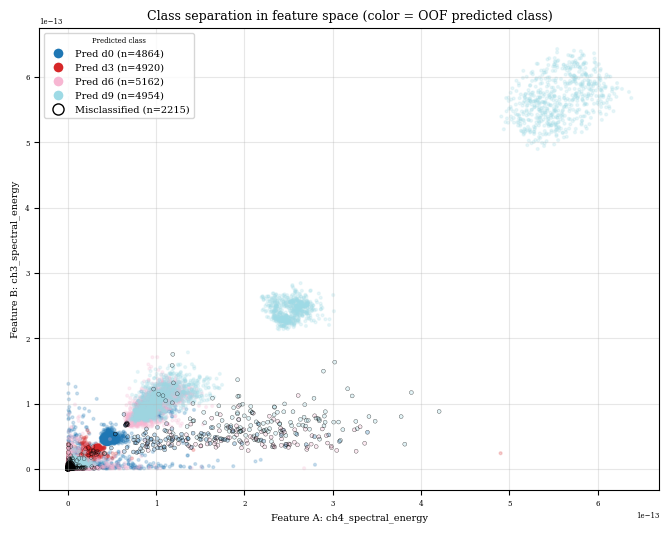

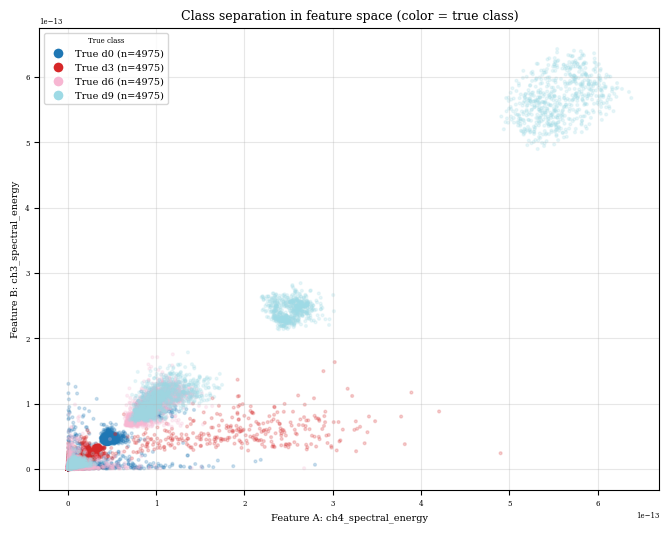

In [32]:
feature_space_plot_info_pred = plot_feature_space_predicted_classes(
    feature_a_name="ch4_spectral_energy",
    feature_b_name="ch3_spectral_energy",
    color_palette="tab20",
    marker_size=4,
    show_misclassified=True,
    alpha=0.2
)

feature_space_plot_info_true = plot_feature_space_true_classes_with_pred_overlay(
    feature_a_name="ch4_spectral_energy",
    feature_b_name="ch3_spectral_energy",
    color_palette="tab20",
    marker_size=4,
    show_misclassified=False,
    alpha=0.2
)



Top feature 1/10: ch3_ptp


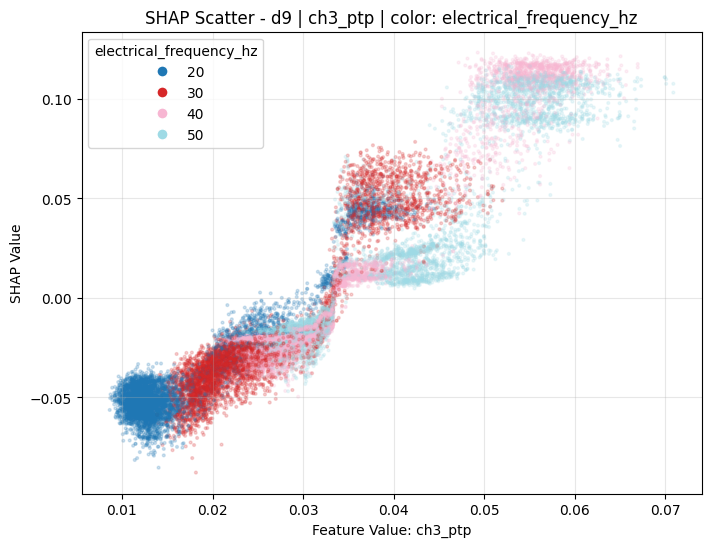

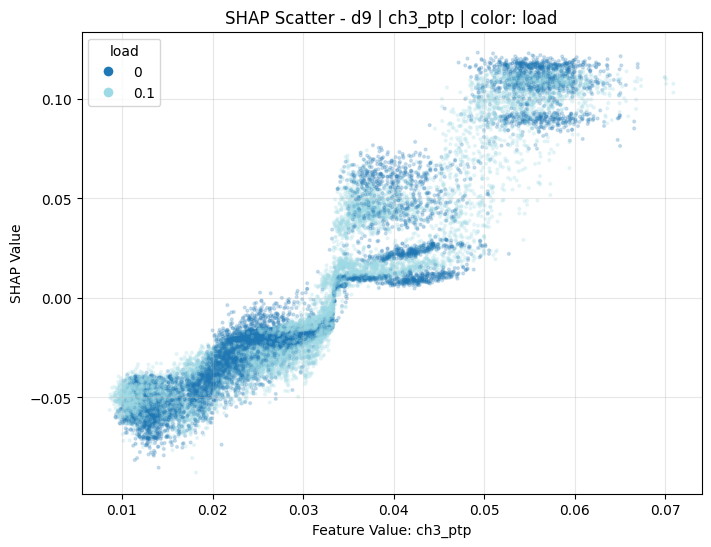

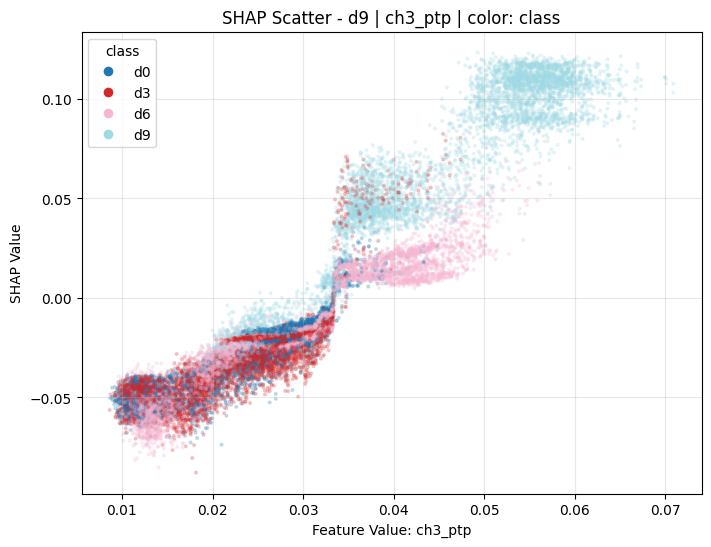


Top feature 2/10: ch4_ptp


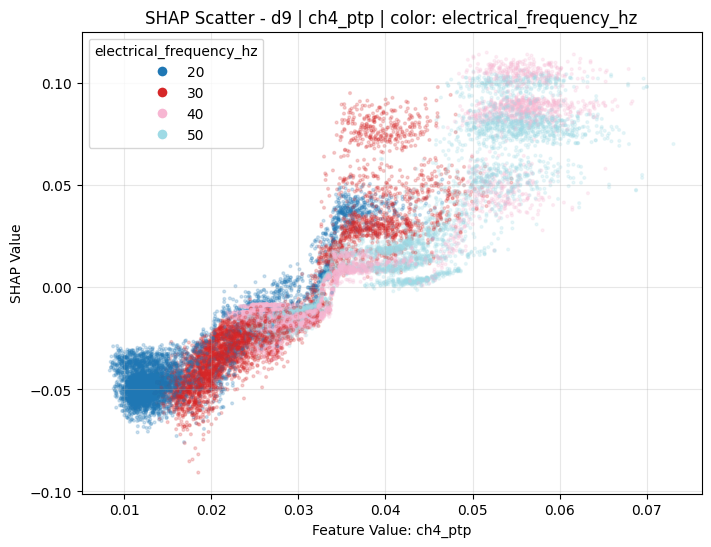

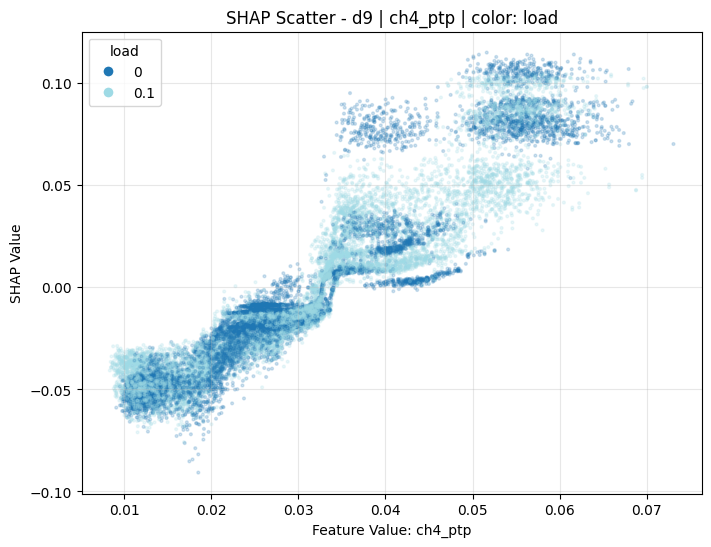

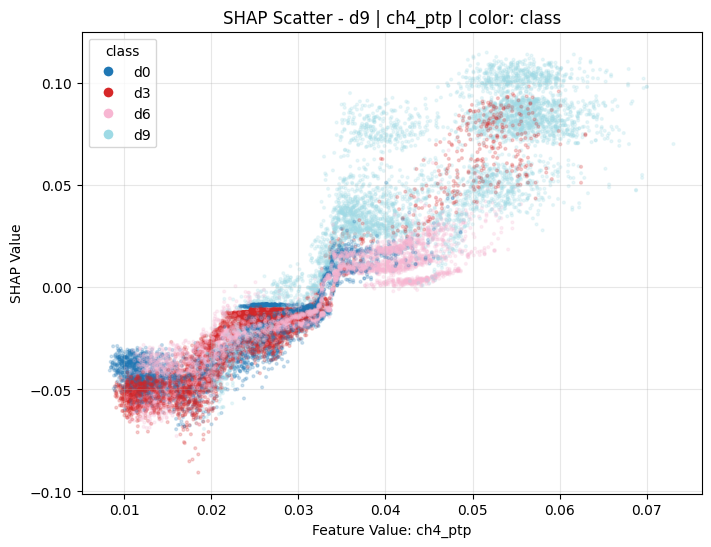


Top feature 3/10: ch2_ptp


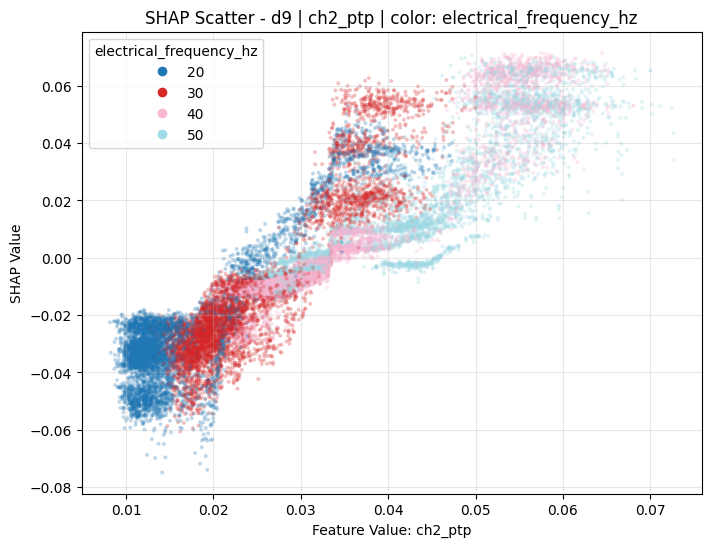

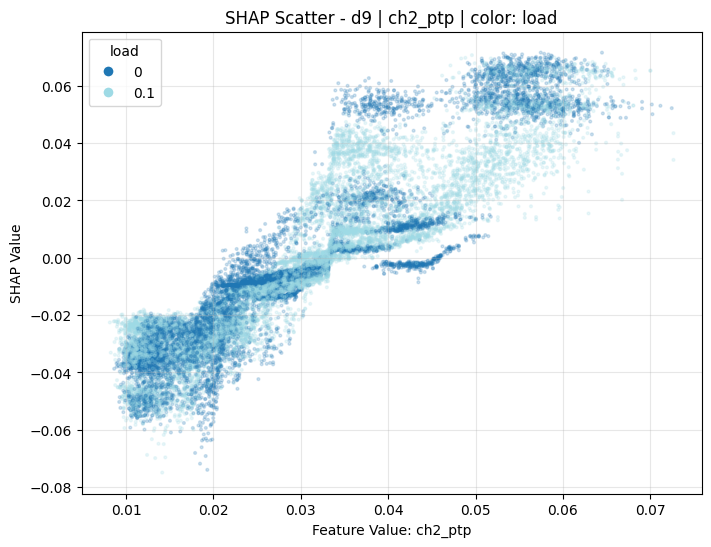

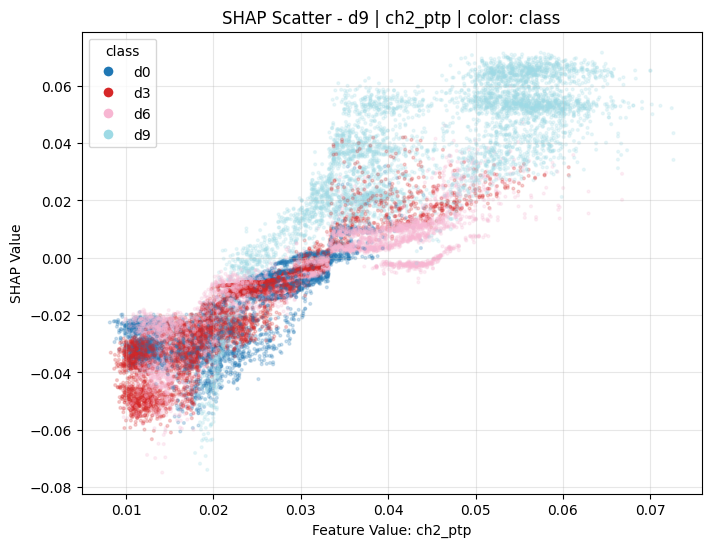


Top feature 4/10: ch1_ptp


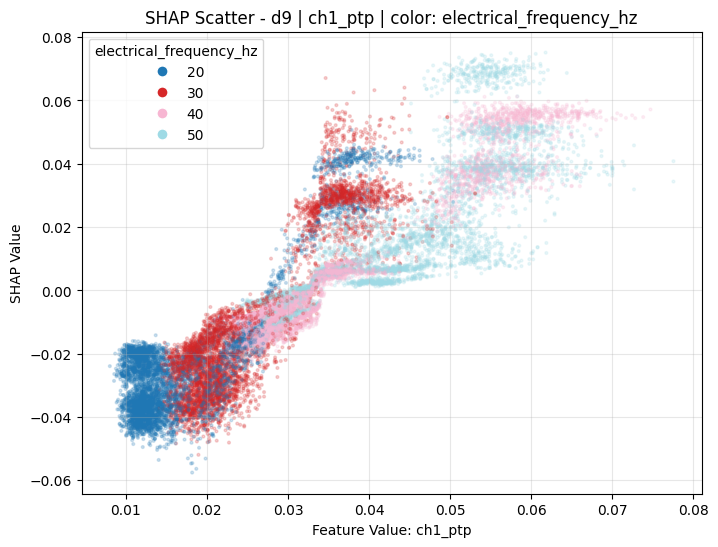

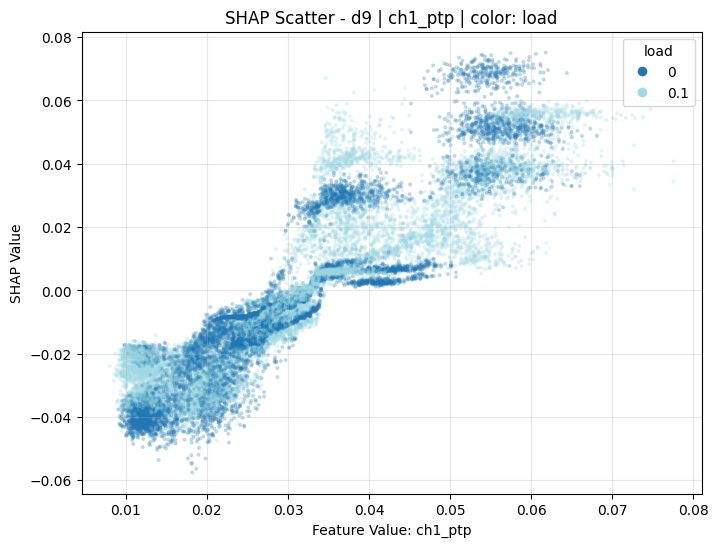

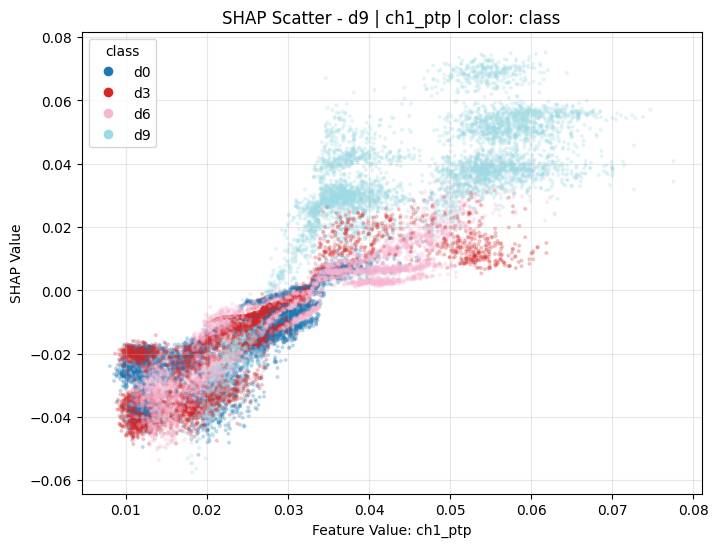


Top feature 5/10: ch3_rms


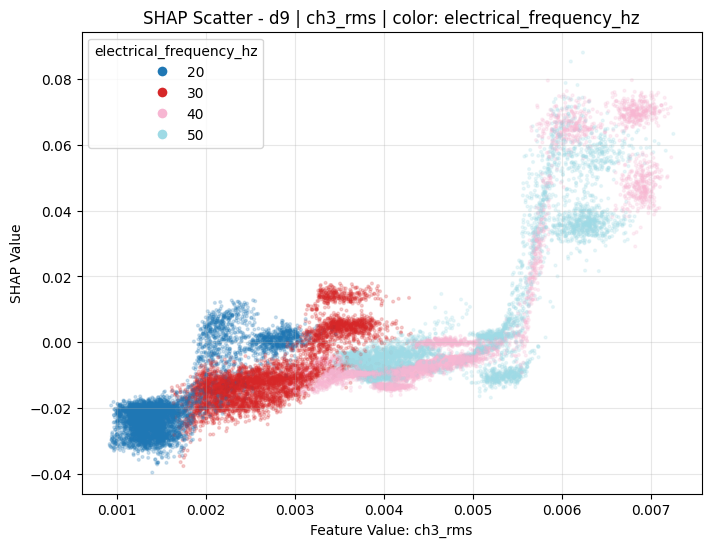

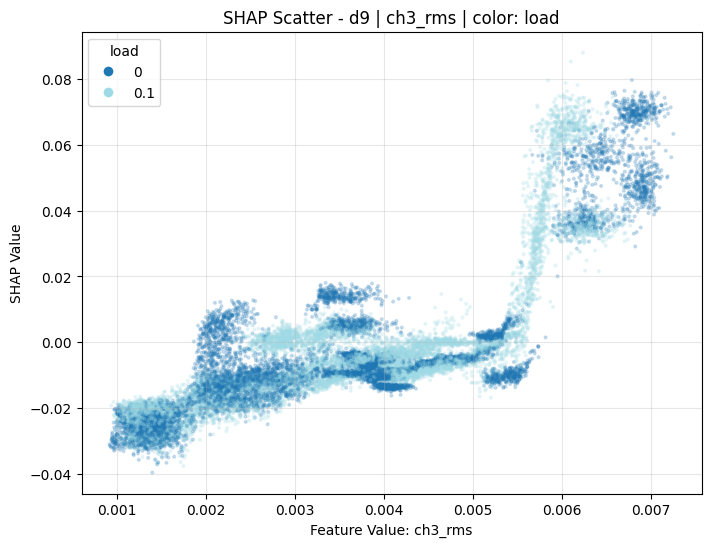

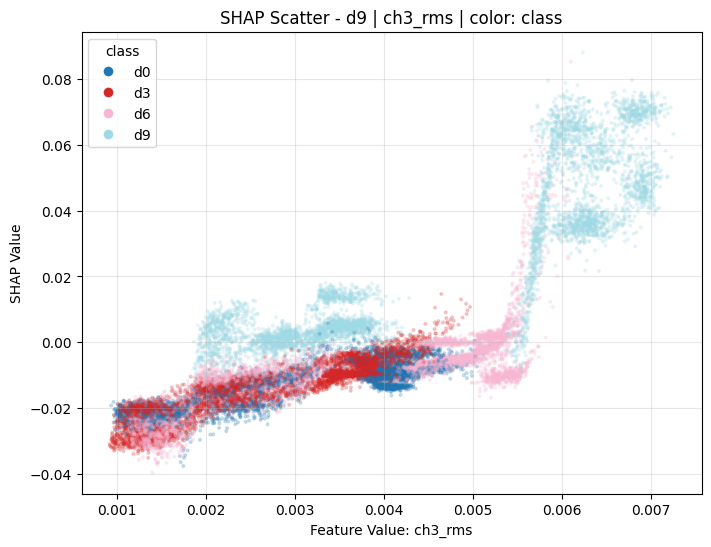


Top feature 6/10: ch4_rms


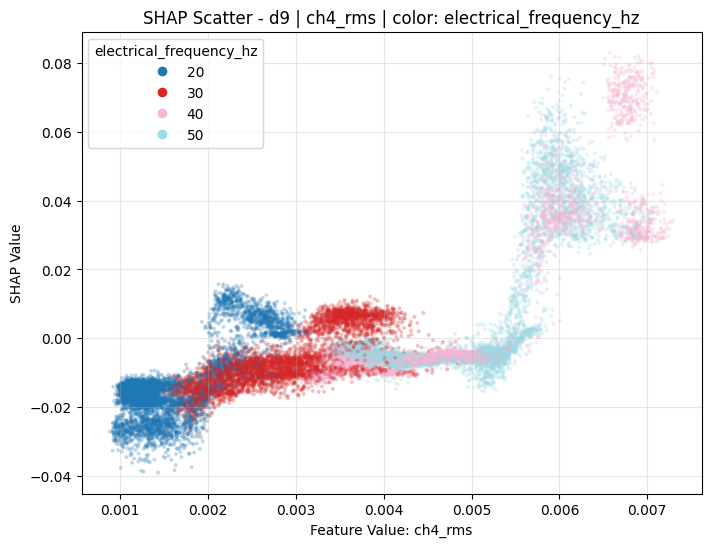

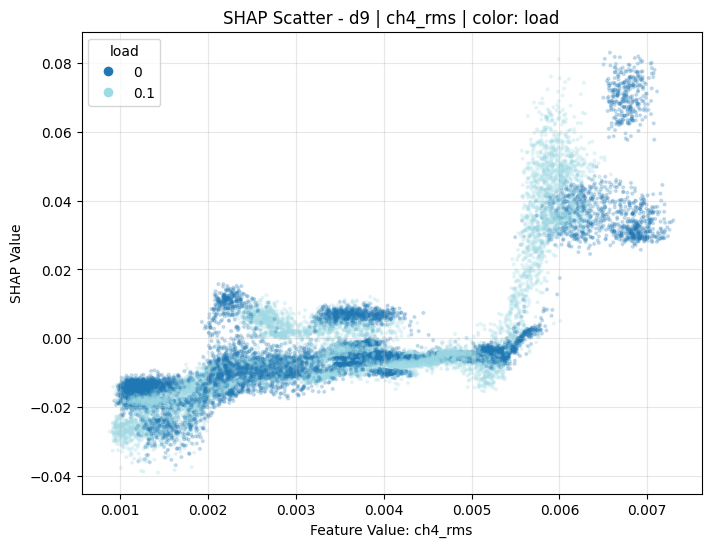

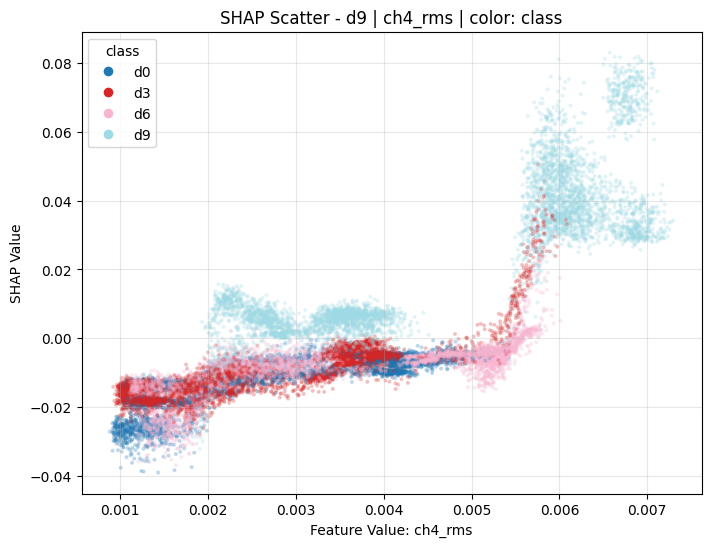


Top feature 7/10: ch2_spectral_spread


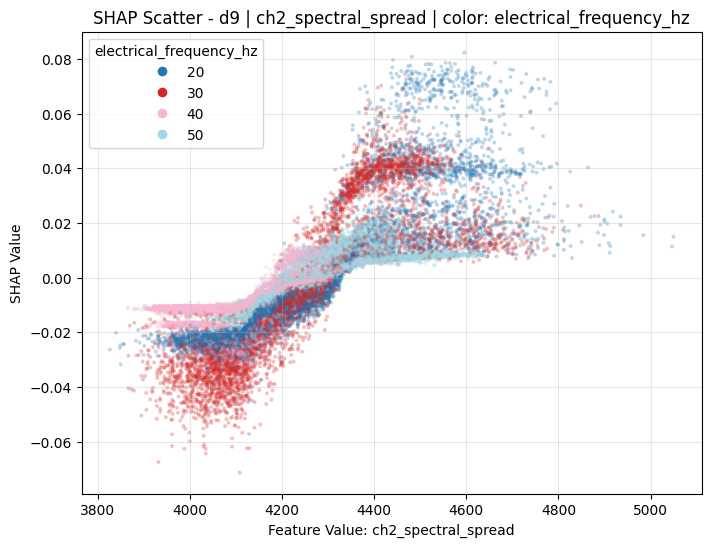

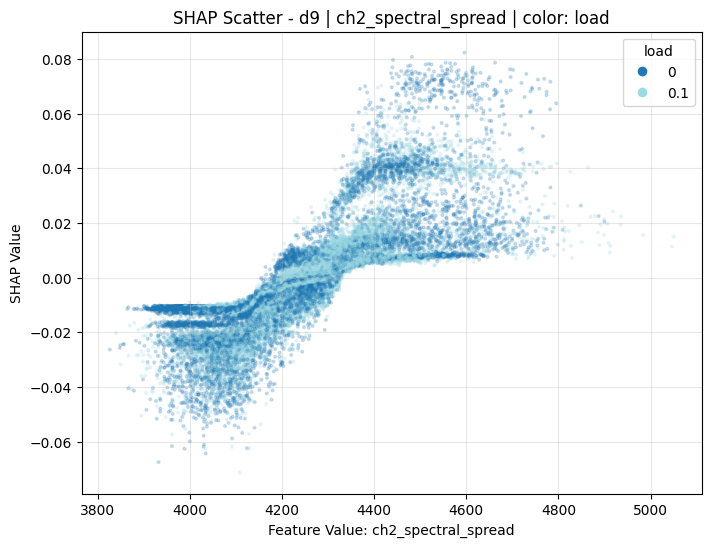

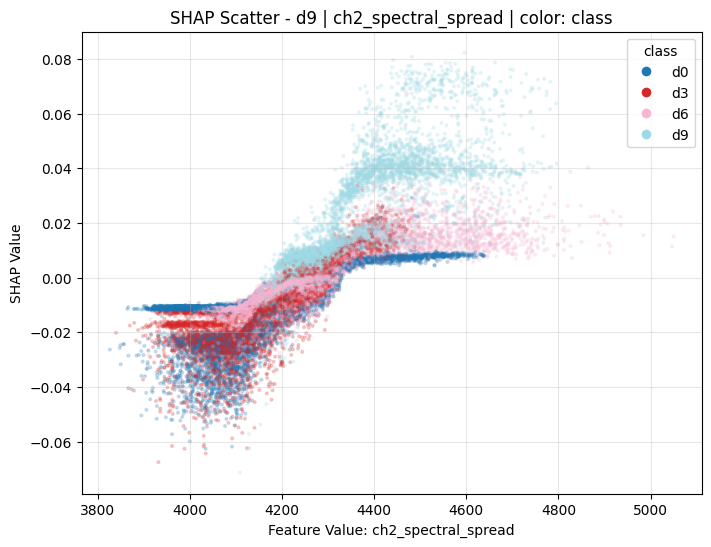


Top feature 8/10: ch1_spectral_spread


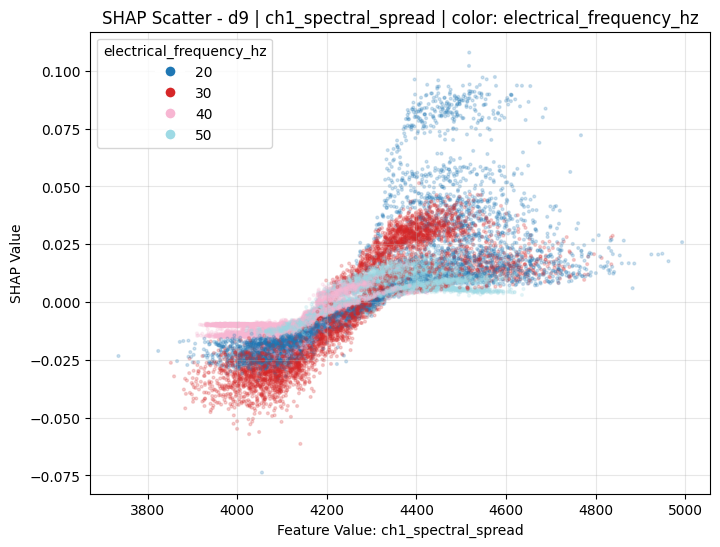

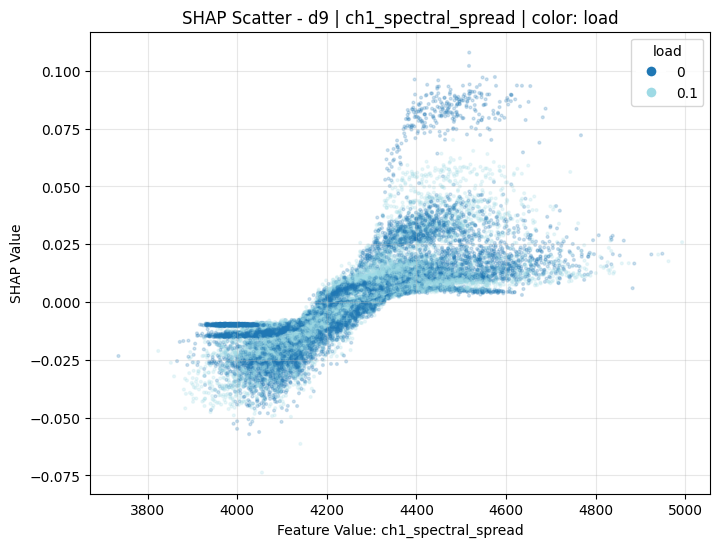

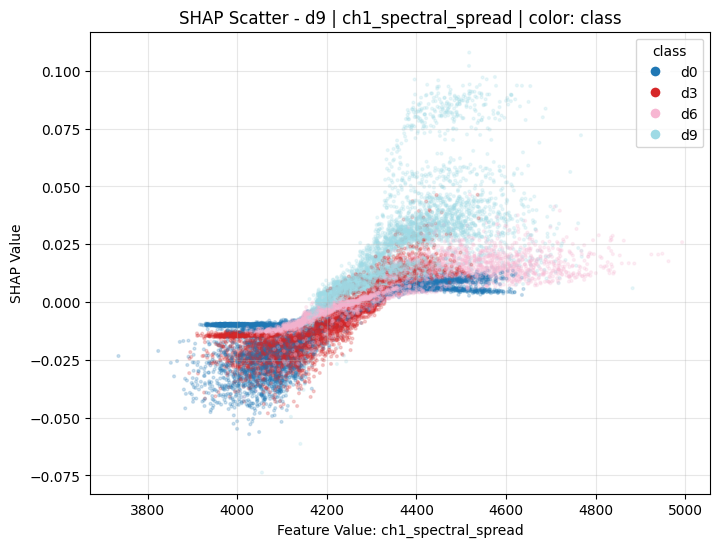


Top feature 9/10: ch2_rms


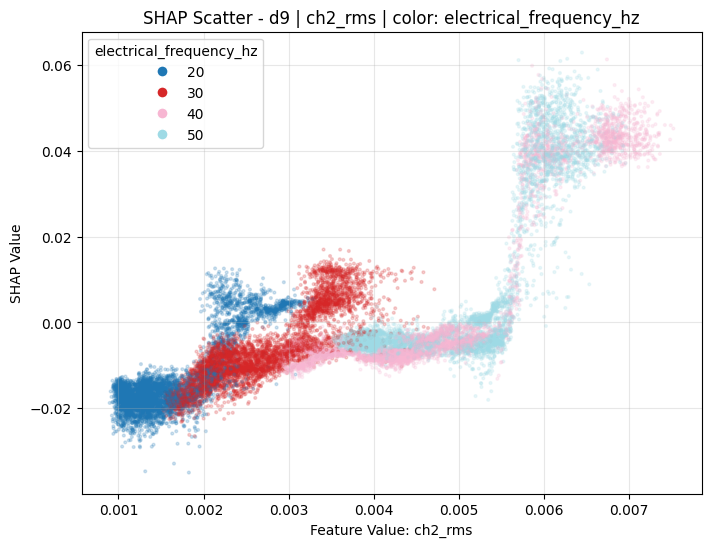

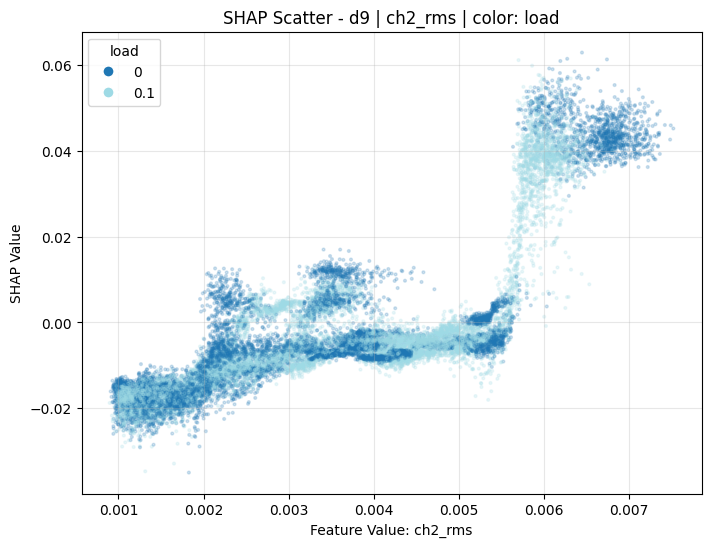

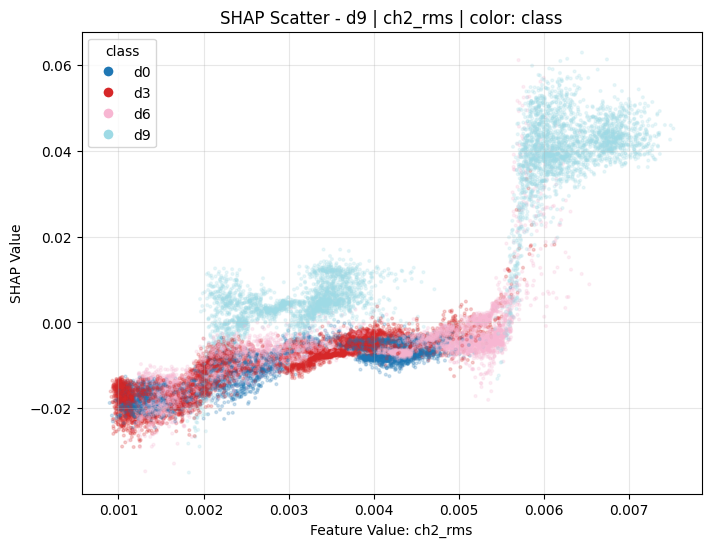


Top feature 10/10: ch1_kurtosis


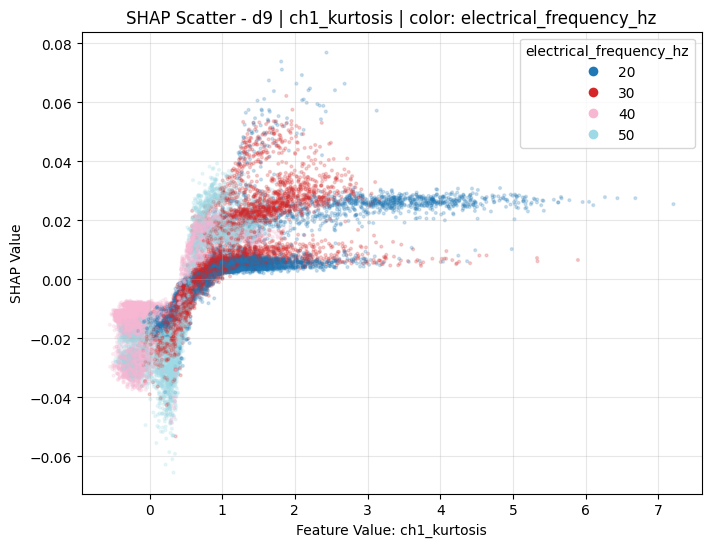

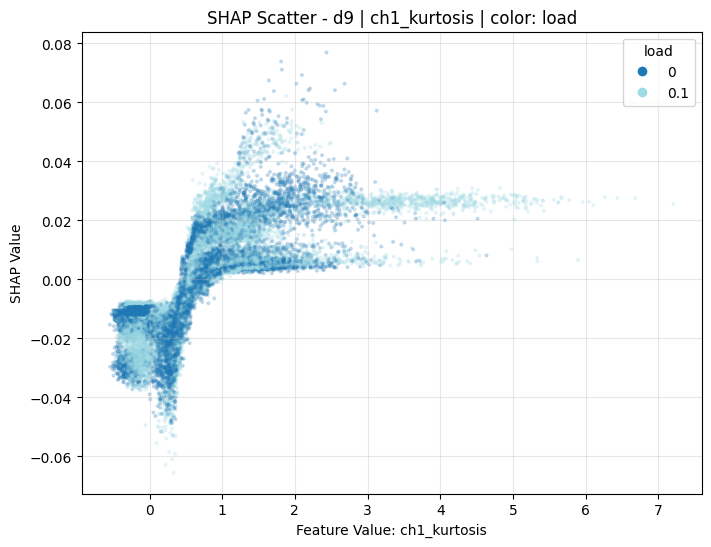

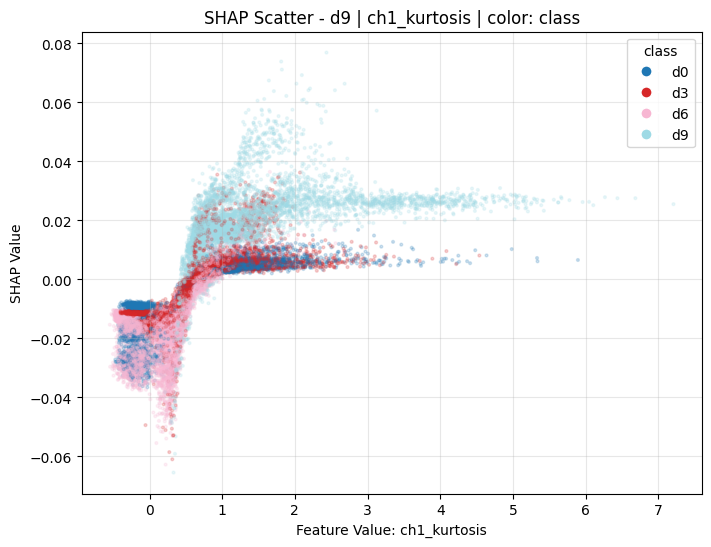


Generated 30 SHAP scatter plots for class 'd9'.
Expected plot count: 10 features x 3 colors = 30
First plot color categories: {'20': 4976, '30': 4974, '40': 4974, '50': 4976}
Last plot color categories: {'d0': 4975, 'd3': 4975, 'd6': 4975, 'd9': 4975}
feature-space predicted-class plot info: {'feature_a_name': 'ch4_spectral_energy', 'feature_b_name': 'ch1_spectral_spread', 'feature_a_idx': 45, 'feature_b_idx': 7, 'n_points': 19900, 'predicted_class_counts': {'0': 4864, '1': 4920, '2': 5162, '3': 4954}, 'misclassified_count': 2215, 'subset_accuracy': 0.8886934673366834}
feature-space true-class plot info: {'feature_a_name': 'ch4_spectral_energy', 'feature_b_name': 'ch1_spectral_spread', 'feature_a_idx': 45, 'feature_b_idx': 7, 'n_points': 19900, 'true_class_counts': {'0': 4975, '1': 4975, '2': 4975, '3': 4975}, 'misclassified_count': 2215, 'subset_accuracy': 0.8886934673366834}


In [11]:


target_class_name = "d9"
n_top_features = 10
color_keys = ["electrical_frequency_hz", "load", "class"]

resolved_class_names = class_names if "class_names" in globals() else labels_order
target_class_idx = _resolve_class_idx(
    class_name=target_class_name,
    class_names=list(resolved_class_names),
)

top_n = min(int(n_top_features), mean_signed_shap_per_class.shape[1])
if top_n <= 0:
    raise ValueError("n_top_features must be >= 1.")

top_feature_idx = np.argsort(mean_signed_shap_per_class[target_class_idx])[::-1][:top_n]
top_feature_names = [feature_names[i] for i in top_feature_idx]

all_plot_info = []
for rank, feat_name in enumerate(top_feature_names, start=1):
    print(f"\nTop feature {rank}/{top_n}: {feat_name}")
    for color_key in color_keys:
        plot_info = plot_shap_scatter(
            class_name=target_class_name,
            feature_name=feat_name,
            color_by=color_key,
            marker_size=2,
            alpha=0.2
        )
        all_plot_info.append(plot_info)

print(f"\nGenerated {len(all_plot_info)} SHAP scatter plots for class '{target_class_name}'.")
print(f"Expected plot count: {top_n} features x {len(color_keys)} colors = {top_n * len(color_keys)}")
print("First plot color categories:", all_plot_info[0]["color_categories"] if all_plot_info else None)
print("Last plot color categories:", all_plot_info[-1]["color_categories"] if all_plot_info else None)
print("feature-space predicted-class plot info:", feature_space_plot_info_pred)
print("feature-space true-class plot info:", feature_space_plot_info_true)

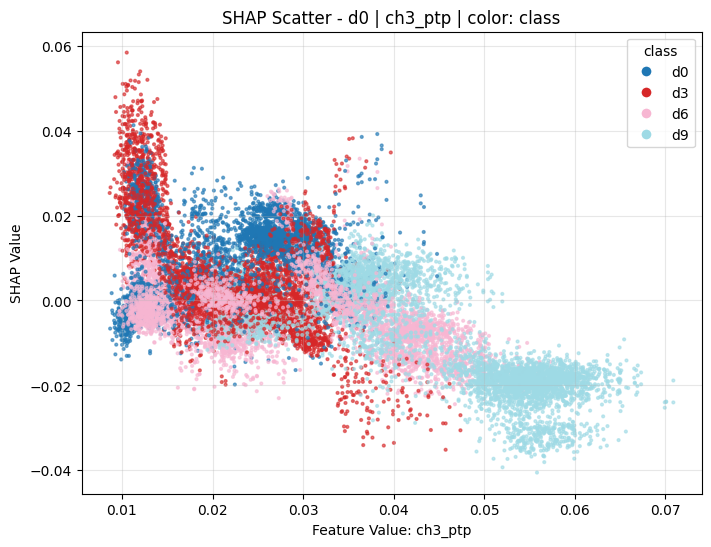

{'class_name': 'd0',
 'feature_name': 'ch3_ptp',
 'class_idx': 0,
 'feature_idx': 25,
 'n_points': 19900,
 'color_by': 'class',
 'color_categories': {'d0': 4975, 'd3': 4975, 'd6': 4975, 'd9': 4975}}

In [12]:
plot_shap_scatter(
            class_name="d0",
            feature_name="ch3_ptp",
            color_by="class",
            marker_size=2
)

In [13]:
# Strict validation checks
try:
    plot_shap_scatter(
        class_name="d0",
        feature_name="ch2_spectral_energy",
        color_by="speed_condition_does_not_exist",
    )
except ValueError as exc:
    print("Expected error:", exc)
else:
    raise AssertionError("Expected ValueError for unknown metadata key.")

try:
    plot_shap_dependence_interaction(
        class_name="d0",
        feature_name="ch2_spectral_energy",
        interaction_feature_name="feature_does_not_exist",
    )
except ValueError as exc:
    print("Expected error:", exc)
else:
    raise AssertionError("Expected ValueError for unknown interaction feature name.")

Expected error: Metadata key 'speed_condition_does_not_exist' not found at sample index 5.
Expected error: Unknown feature_name='feature_does_not_exist'. Available feature examples: ch1_rms, ch1_ptp, ch1_skewness, ch1_kurtosis, ch1_crest_factor, ch1_form_factor, ch1_spectral_centroid, ch1_spectral_spread, ch1_spectral_rolloff, ch1_spectral_energy, ch1_spectral_entropy, ch1_spectral_flatness, ...


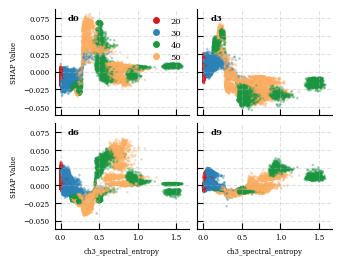

Generated subplot count: 4
Classes used: ['d0', 'd3', 'd6', 'd9']
Feature used: ch3_spectral_entropy
Color key: electrical_frequency_hz


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Enhanced version: supports drawing into provided subplot axes while keeping old behavior.
def plot_shap_scatter(
    class_name,
    feature_name,
    use_abs=False,
    alpha=0.6,
    figsize=(8, 6),
    marker_size=2,
    color_by=None,
    color_palette="contrast4",
    ax=None,
    show=True,
    show_legend=True,
):
    """Plot SHAP scatter by class and feature, with optional metadata colorization.

    Works as standalone plot (default) or inside a provided Matplotlib axis for subplots.
    """
    if not isinstance(class_name, str) or class_name.strip() == "":
        raise ValueError("class_name must be a non-empty string.")
    if not isinstance(feature_name, str) or feature_name.strip() == "":
        raise ValueError("feature_name must be a non-empty string.")
    if color_by is not None and (not isinstance(color_by, str) or color_by.strip() == ""):
        raise ValueError("color_by must be None or a non-empty metadata key string.")

    resolved_class_names = class_names if "class_names" in globals() else labels_order
    class_idx = _resolve_class_idx(class_name=class_name, class_names=list(resolved_class_names))
    feature_idx = _resolve_feature_idx(feature_name=feature_name, feature_names=list(feature_names))

    first_shap = shap_res["shap_values_per_fold"][0]["shap_values"]
    layout = _infer_shap_layout(first_shap)
    if layout["n_classes"] == 1 and class_idx != 0:
        raise ValueError("Binary SHAP output has only one class; use class_name of index 0.")

    x_vals, y_vals, color_vals = _collect_scatter_data(
        shap_res=shap_res,
        features=features,
        class_idx=class_idx,
        feature_idx=feature_idx,
        layout=layout,
        color_by=color_by,
        metadata_list=win_metadata if color_by is not None else None,
    )

    y_plot = np.abs(y_vals) if use_abs else y_vals

    created_local_axis = False
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
        created_local_axis = True

    category_counts = None
    if color_by is None:
        ax.scatter(x=x_vals, y=y_plot, alpha=alpha, s=marker_size)
    else:
        unique_vals = sorted(np.unique(np.asarray(color_vals, dtype=object)), key=lambda x: str(x))

        # High-contrast fixed palette: Red, Blue, Green, Yellow
        if color_palette == "contrast4":
            palette = ["#d7191c", "#2b83ba", "#1a9641", "#fdae61"]
            value_to_color = {val: palette[i % len(palette)] for i, val in enumerate(unique_vals)}
        else:
            cmap = plt.get_cmap(color_palette, max(len(unique_vals), 1))
            value_to_color = {val: cmap(i) for i, val in enumerate(unique_vals)}

        point_colors = [value_to_color[val] for val in color_vals]
        ax.scatter(x=x_vals, y=y_plot, c=point_colors, alpha=alpha, s=marker_size)

        handles = [
            Line2D(
                [0],
                [0],
                marker="o",
                color="w",
                label=str(val),
                markerfacecolor=value_to_color[val],
                markersize=6,
            )
            for val in unique_vals
        ]
        if show_legend:
            ax.legend(handles=handles, loc="best", frameon=False, fontsize=6, title_fontsize=7)
        category_counts = {str(val): int(np.sum(color_vals == val)) for val in unique_vals}

    ax.grid(True, alpha=0.3)

    if show and created_local_axis:
        plt.tight_layout()
        plt.show()

    return {
        "class_name": class_name,
        "feature_name": feature_name,
        "class_idx": class_idx,
        "feature_idx": feature_idx,
        "n_points": int(len(x_vals)),
        "color_by": color_by,
        "color_categories": category_counts,
    }

# Configurable class loop and one fixed feature across all subplots
target_class_names = ["d0", "d3", "d6", "d9"]
target_feature_name = "ch3_spectral_entropy"
target_color_key = "electrical_frequency_hz"

if len(target_class_names) != 4:
    raise ValueError("target_class_names must contain exactly 4 classes for 2x2 layout.")

# IEEE-like publication style
plt.rcParams["font.family"] = "serif"
plt.rcParams["font.size"] = 5
plt.rcParams["axes.titlesize"] = 9
plt.rcParams["axes.labelsize"] = 7
plt.rcParams["legend.fontsize"] = 7

fig, axes = plt.subplots(2, 2, figsize=(3.299213, 2.53937), sharey=True, sharex=True, constrained_layout=True)
axes = axes.flatten()

subplot_infos = []
for i, class_name in enumerate(target_class_names):
    info = plot_shap_scatter(
        class_name=class_name,
        feature_name=target_feature_name,
        color_by=target_color_key,
        marker_size=1,
        alpha=0.28,
        color_palette="contrast4",
        ax=axes[i],
        show=False,
        show_legend=(i == 0),
    )
    subplot_infos.append(info)
    axes[i].annotate(
        class_name,
        xy=(0.1, 0.95),
        xycoords="axes fraction",
        fontsize=6,
        fontweight="bold",
        ha="left",
        va="top",
    )
    axes[i].grid(axis="both", linestyle="--", alpha=0.35)
    axes[i].tick_params(direction="in", length=4, width=0.8)
    axes[i].spines["right"].set_visible(False)
    axes[i].spines["top"].set_visible(False)

for ax in axes.flat:
    ax.set_xlabel("")
    ax.set_ylabel("")

axes[0].set_ylabel("SHAP Value", fontsize=5)
axes[2].set_ylabel("SHAP Value", fontsize=5)
axes[2].set_xlabel(target_feature_name, fontsize=5)
axes[3].set_xlabel(target_feature_name, fontsize=5)

# Optional export for paper/report
# plt.savefig("test_output/pic/shap_scatter_4class_subplot.png", dpi=300, bbox_inches="tight")

plt.savefig("my_plot.tiff", format="tiff", dpi=300, bbox_inches="tight")

plt.show()

print("Generated subplot count:", len(subplot_infos))
print("Classes used:", target_class_names)
print("Feature used:", target_feature_name)
print("Color key:", target_color_key)